# Clustering Analysis

Train depth-2 and depth-4 GIN models on one shared 80/20 organoid split, cluster their final local node embeddings into six Gaussian-mixture components, and compare the resulting biological structure.

Clusters are relabeled by increasing median true curvature, so `C0` always has the lowest median curvature within a model depth. All summaries and derived arrays required to recreate the static figures are saved without storing full trained models or the full graph dataset.

**Setup**

In [61]:
import copy
import json
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"
sys.path.append(str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

In [62]:
# Data and filtering: matched to lineage_removal.ipynb / ablation_analysis.ipynb
EXPERIMENT_GROUP = "clustering_analysis"
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0

USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

TIMEPOINT_FILTER_MODE = "day3p5"  # "rest", "day3p5", or "all"
DAY3P5_TIMEPOINT = "day3p5"
FILL_MISSING_COMPLEXITY = True
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# One shared split. The forced organoid matches scan_model_depth_motifs.ipynb.
VAL_FRAC = 0.2
SPLIT_SEED = 420
FORCED_VAL_KEYS = {
    # ("20251201", "day4p5_B03_144"),
}

# Models and training
MODEL_DEPTHS = [2, 4]
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}
SAVE_MODEL_CHECKPOINTS = False

# Embedding clustering
N_CLUSTERS = 6
CLUSTERING_METHOD = "gmm"
CLUSTER_COVARIANCE_TYPE = "full"
EMBEDDING_VARIANT = "local"
RESIDUALIZE_GLOBAL_EMBEDDINGS = False
STANDARDIZE_EMBEDDINGS = True
PCA_DIM = 32
CLUSTER_SEED = 69
EMBEDDING_BATCH_SIZE = 128

# t-SNE visualization. A stratified sample keeps the plot tractable while
# cluster assignments and embeddings are saved for every validation node.
TSNE_MAX_POINTS = 30000  # None uses every validation node
TSNE_PERPLEXITY = 40
TSNE_LEARNING_RATE = "auto"
TSNE_N_ITER = 1000
TSNE_SEED = 420

# Cluster-wise accuracy filter. Each node represents the center of a
# depth-specific receptive-field subgraph. The worst-error fraction is removed
# independently within every cluster.
ERROR_FILTER_DROP_FRACTION = 0.50
ERROR_FILTER_MIN_RETAINED_PER_CLUSTER = 1

# Exemplars and crypt-distance categories
EXEMPLARS_PER_CLUSTER = 4
EXEMPLAR_SAMPLING_STRATEGY = "marker_enriched"  # "marker_enriched" or "confidence"
EXEMPLAR_MARKER_THRESHOLD = 0.5
EXEMPLAR_MIN_GLOBAL_POSITIVE_NODES = 10
EXEMPLAR_MIN_CLUSTER_POSITIVE_NODES = 1
EXEMPLAR_MIN_ENRICHMENT_RATIO = 1.5

DCRYPT_FIELD = "d_crypts_graph"
DCRYPT_CRYPT_MAX = 0.7
DCRYPT_NECK_MAX = 1.2
DCRYPT_NO_CRYPT_LABEL = "No crypt"
DCRYPT_CRYPT_LABEL = f"Crypt (< {DCRYPT_CRYPT_MAX:g})"
DCRYPT_NECK_LABEL = (
    f"Neck ({DCRYPT_CRYPT_MAX:g} - {DCRYPT_NECK_MAX:g})"
)
DCRYPT_VILLUS_LABEL = f"Villus (> {DCRYPT_NECK_MAX:g})"
DCRYPT_BIN_ORDER = [
    DCRYPT_NO_CRYPT_LABEL,
    DCRYPT_CRYPT_LABEL,
    DCRYPT_NECK_LABEL,
    DCRYPT_VILLUS_LABEL,
]

# Mesh visualization
MESH_VIEW = dict(azim=-135, elev=50)
MESH_FIG_HEIGHT = 570
CURVATURE_COLORSCALE = "RdBu_r"
CENTER_CURVATURE_AT_ZERO = True

# Output
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"depths-{'-'.join(map(str, MODEL_DEPTHS))}_k{N_CLUSTERS}_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
ARRAYS_DIR = SAVE_DIR / "arrays"
MODELS_DIR = SAVE_DIR / "models"
for directory in (FIGURES_DIR, TABLES_DIR, ARRAYS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
if SAVE_MODEL_CHECKPOINTS:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)


def set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_all_seeds(SPLIT_SEED)

**Utilities**

In [63]:
def safe_filename(name):
    text = str(name).strip().replace("/", "_")
    cleaned = "".join(
        char if (char.isalnum() or char in "._-") else "_" for char in text
    ).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def save_mpl_figure(fig, name, *, dpi=300):
    stem = safe_filename(name)
    for suffix in ("pdf", "png"):
        fig.savefig(
            FIGURES_DIR / f"{stem}.{suffix}",
            dpi=dpi,
            bbox_inches="tight",
        )


def save_plotly_figure(fig, name, *, scale=2):
    stem = safe_filename(name)
    html_path = FIGURES_DIR / f"{stem}.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")
    png_path = FIGURES_DIR / f"{stem}.png"
    try:
        fig.write_image(str(png_path), scale=scale)
    except Exception as exc:
        print(f"Plotly PNG export skipped for {stem}: {exc}")
    return html_path


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(key): jsonable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(value) for value in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (torch.dtype, np.dtype)):
        return str(obj)
    return obj


def select_target_column(values, target_index=0):
    array = np.asarray(values)
    if array.ndim == 1:
        return array.reshape(-1)
    if array.ndim == 2 and array.shape[1] == 1:
        return array[:, 0]
    if array.ndim == 2:
        return array[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D values, got {array.shape}.")


def graph_slice_bounds(graphs_in, graph_index):
    sizes = [int(graph.x.shape[0]) for graph in graphs_in]
    start = sum(sizes[:int(graph_index)])
    return start, start + sizes[int(graph_index)]


def min_node_dcrypt(raw, n_nodes):
    array = np.asarray(raw, dtype=float)
    if array.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    if array.ndim == 0:
        return np.full(n_nodes, float(array), dtype=float)
    if array.ndim == 1:
        if array.shape[0] == n_nodes:
            return array.astype(float)
        if array.shape[0] == 1:
            return np.full(n_nodes, float(array[0]), dtype=float)
        raise ValueError(
            f"Cannot align dcrypt length {array.shape[0]} to {n_nodes} nodes."
        )
    if n_nodes in array.shape:
        node_axis = list(array.shape).index(n_nodes)
        array = np.moveaxis(array, node_axis, 0).reshape(n_nodes, -1)
        finite = np.isfinite(array)
        values = np.min(np.where(finite, array, np.inf), axis=1)
        values[~np.any(finite, axis=1)] = np.nan
        return values
    raise ValueError(
        f"Cannot identify node axis in dcrypt shape {array.shape} for {n_nodes} nodes."
    )


def dcrypt_category(value):
    if not np.isfinite(value):
        return DCRYPT_NO_CRYPT_LABEL
    if value < DCRYPT_CRYPT_MAX:
        return DCRYPT_CRYPT_LABEL
    if value <= DCRYPT_NECK_MAX:
        return DCRYPT_NECK_LABEL
    return DCRYPT_VILLUS_LABEL


def stratified_tsne_indices(labels, max_points, seed):
    labels = np.asarray(labels, dtype=int)
    if max_points is None or len(labels) <= int(max_points):
        return np.arange(len(labels), dtype=int)
    rng = np.random.default_rng(seed)
    selected = []
    unique, counts = np.unique(labels, return_counts=True)
    raw_targets = counts / counts.sum() * int(max_points)
    targets = np.maximum(1, np.floor(raw_targets).astype(int))
    while targets.sum() > int(max_points):
        candidates = np.where(targets > 1)[0]
        targets[candidates[np.argmax(targets[candidates])]] -= 1
    while targets.sum() < int(max_points):
        room = counts - targets
        targets[np.argmax(room)] += 1
    for cluster, target in zip(unique, targets):
        candidates = np.flatnonzero(labels == cluster)
        selected.extend(
            rng.choice(candidates, size=min(int(target), len(candidates)), replace=False)
        )
    return np.sort(np.asarray(selected, dtype=int))


def cluster_accuracy_filter_mask(
    labels,
    y_true,
    y_pred,
    *,
    drop_fraction=0.5,
    min_retained_per_cluster=1,
):
    """Retain the lowest-error fraction independently within each cluster."""
    labels = np.asarray(labels, dtype=int)
    squared_error = np.square(
        np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    )
    if not 0 <= float(drop_fraction) < 1:
        raise ValueError("drop_fraction must satisfy 0 <= drop_fraction < 1.")

    retained = np.zeros(len(labels), dtype=bool)
    within_cluster_rank = np.full(len(labels), -1, dtype=int)
    for cluster in np.unique(labels):
        indices = np.flatnonzero(labels == cluster)
        sortable_error = np.where(
            np.isfinite(squared_error[indices]),
            squared_error[indices],
            np.inf,
        )
        order = np.argsort(sortable_error, kind="stable")
        within_cluster_rank[indices[order]] = np.arange(len(indices), dtype=int)
        n_keep = max(
            int(min_retained_per_cluster),
            int(np.ceil((1.0 - float(drop_fraction)) * len(indices))),
        )
        retained[indices[order[:min(n_keep, len(indices))]]] = True
    return retained, squared_error, within_cluster_rank


def dcrypt_fraction_table(labels, values, *, subset_mask=None):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    if subset_mask is None:
        subset_mask = np.ones(len(labels), dtype=bool)
    else:
        subset_mask = np.asarray(subset_mask, dtype=bool)

    categories = np.asarray([dcrypt_category(value) for value in values], dtype=object)
    rows = []
    index = []
    group_masks = [subset_mask]
    index.append("All")
    for cluster in range(N_CLUSTERS):
        group_masks.append(subset_mask & (labels == cluster))
        index.append(cluster)

    for mask in group_masks:
        denominator = int(mask.sum())
        rows.append({
            category: (
                float(np.sum(mask & (categories == category)) / denominator)
                if denominator
                else np.nan
            )
            for category in DCRYPT_BIN_ORDER
        })
    return pd.DataFrame(rows, index=index, columns=DCRYPT_BIN_ORDER)


## 1. Load And Filter Data

In [64]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
metadata = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, metadata, exclude_keys=None)
graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    marker_names = [f"marker_{index}" for index in range(int(graphs[0].x.size(1)))]
print(f"Loaded {len(graphs)} organoids and {len(marker_names)} markers.")

if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={DAY3P5_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={DAY3P5_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE not in (None, "all"):
    raise ValueError(
        'TIMEPOINT_FILTER_MODE must be "rest", "day3p5", or "all".'
    )

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )

graphs, spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)
spherical = filter_graphs_by_marker_diversity(
    spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)
graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)
if INTERPOLATE_TARGET_OUTLIERS:
    graphs, target_outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    target_outlier_info = None

print(f"After filtering: {len(graphs)} organoids.")

Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids and 7 markers.
filter_graphs_by_metadata(key='timepoint'): kept 289 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              289    289    1.000
20250929         day4                  0    342    0.000
20250929         day4p5                0    104    0.000
20250929         day4p5-more           0    411    0.000
20251201         day4p5                0    277    0.000
filter_graphs_by_blacklist(n_keys=6): kept 289 / 289 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              289    289    1.000
filter_graphs_by_sphericity(max_sphericity=0.92): kept 167 / 289 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              167

## 2. Split And Transform

In [65]:
from src.data.metadata import (
    add_log_metadata_features,
    infer_global_dim,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

FIELD_SPECS = [{
    "meta_keys": [
        "log_surface_area",
        "log_volume",
        "log_volume_over_area",
        "log_num_cells",
    ],
    "attr_name": "global_feat",
    "kind": "graph_vector",
    "dtype": torch.float32,
}]

if USE_GLOBAL_FEATURES:
    graphs = promote_metadata_to_graph_tensors(
        add_log_metadata_features(graphs, inplace=False),
        FIELD_SPECS,
        inplace=False,
    )
else:
    raise ValueError("This notebook requires USE_GLOBAL_FEATURES=True.")

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
    inplace=False,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)
g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

global_center, global_scale = standardize_graph_global_features(
    g_train,
    g_val,
    attr_name="global_feat",
    robust=False,
)
target_transform = AsinhStandardizeTransform(robust=True)
target_transform.fit(g_train)
target_transform.transform_graphs(g_train, in_place=True)
target_transform.transform_graphs(g_val, in_place=True)

split_summary_df = pd.DataFrame([{
    "n_graphs_filtered": len(graphs),
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "n_train_nodes": sum(int(graph.x.shape[0]) for graph in g_train),
    "n_val_nodes": sum(int(graph.x.shape[0]) for graph in g_val),
    "val_frac": VAL_FRAC,
    "split_seed": SPLIT_SEED,
    "forced_val_keys": repr(sorted(FORCED_VAL_KEYS)),
}])
split_summary_df.to_csv(TABLES_DIR / "split_summary.csv", index=False)
display(split_summary_df)

Split -> train: 113 | val: 28


,n_graphs_filtered,n_train_graphs,n_val_graphs,n_train_nodes,n_val_nodes,val_frac,split_seed,forced_val_keys
0,141,113,28,26496,7149,0.2,420,[]


## 3. Train Models And Global Baseline

In [66]:
from src.models.baseline import GlobalFeatureMLP
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term


def infer_target_dim(graphs_in):
    y = graphs_in[0].y
    return 1 if y.ndim == 1 else int(y.shape[1])


def make_gin_model(depth):
    return GINCurvature(
        n_markers=int(g_train[0].x.size(1)),
        global_dim=infer_global_dim(g_train),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(depth),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
        target_dim=infer_target_dim(g_train),
    )


def make_global_baseline():
    return GlobalFeatureMLP(
        global_dim=infer_global_dim(g_train),
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        target_dim=infer_target_dim(g_train),
    )


cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=[WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    )],
)
device = cfg.device
trained_models = {}
training_rows = []

set_all_seeds(SPLIT_SEED + 9000)
print("Training global-feature baseline")
global_baseline = make_global_baseline()
global_baseline, baseline_metrics, baseline_history = train(
    global_baseline, g_train, g_val, cfg
)
training_rows.append({
    "model": "GlobalFeatureMLP",
    "depth": np.nan,
    "val_mae_transformed": float(baseline_metrics["val_mae"]),
    "epochs_trained": len(baseline_history["val_mae"]),
})

for depth in MODEL_DEPTHS:
    set_all_seeds(SPLIT_SEED + int(depth))
    print(f"Training GIN depth={depth}")
    model = make_gin_model(depth)
    model, metrics, history = train(model, g_train, g_val, cfg)
    trained_models[int(depth)] = model
    training_rows.append({
        "model": "GINCurvature",
        "depth": int(depth),
        "val_mae_transformed": float(metrics["val_mae"]),
        "epochs_trained": len(history["val_mae"]),
    })
    if SAVE_MODEL_CHECKPOINTS:
        torch.save(
            model.state_dict(),
            MODELS_DIR / f"gin_depth{depth}.pt",
        )

if SAVE_MODEL_CHECKPOINTS:
    torch.save(
        global_baseline.state_dict(),
        MODELS_DIR / "global_feature_baseline.pt",
    )

training_summary_df = pd.DataFrame(training_rows)
training_summary_df.to_csv(TABLES_DIR / "training_summary.csv", index=False)
display(training_summary_df)

Training global-feature baseline
epoch 001 | train loss 0.5879 mae 0.8424 | val loss 0.5866 mae 0.8374
epoch 002 | train loss 0.5567 mae 0.8153 | val loss 0.5580 mae 0.8136
epoch 003 | train loss 0.5319 mae 0.7919 | val loss 0.5360 mae 0.7935
epoch 004 | train loss 0.5125 mae 0.7719 | val loss 0.5203 mae 0.7776
epoch 005 | train loss 0.4994 mae 0.7578 | val loss 0.5099 mae 0.7662
epoch 006 | train loss 0.4916 mae 0.7480 | val loss 0.5043 mae 0.7587
epoch 007 | train loss 0.4863 mae 0.7415 | val loss 0.5027 mae 0.7545
epoch 008 | train loss 0.4857 mae 0.7392 | val loss 0.5038 mae 0.7528
epoch 009 | train loss 0.4863 mae 0.7389 | val loss 0.5059 mae 0.7523
epoch 010 | train loss 0.4888 mae 0.7383 | val loss 0.5074 mae 0.7521
epoch 011 | train loss 0.4905 mae 0.7396 | val loss 0.5073 mae 0.7514
epoch 012 | train loss 0.4900 mae 0.7395 | val loss 0.5058 mae 0.7505
epoch 013 | train loss 0.4877 mae 0.7386 | val loss 0.5032 mae 0.7494
epoch 014 | train loss 0.4860 mae 0.7374 | val loss 0.500

,model,depth,val_mae_transformed,epochs_trained
0,GlobalFeatureMLP,NaN,0.739435,91
1,GINCurvature,2.0,0.649054,188
2,GINCurvature,4.0,0.613945,138


## 4. Six-Cluster Embedding Analysis

In [67]:
from src.analysis.cluster_analysis import (
    build_cluster_exemplar_subgraphs,
    build_marker_enriched_cluster_exemplar_subgraphs,
    cluster_marker_distribution,
    cluster_marker_means,
)
from src.analysis.marker_stats import append_none_marker_column
from src.analysis.motif_clustering import run_embedding_clustering
from src.inference.predict import predict_targets


def inverse_extraction_targets(extraction):
    y_true, y_pred, log_var = target_transform.inverse_distribution(
        extraction.y_true,
        extraction.y_pred,
        log_var=extraction.log_var,
        graphs=g_val,
    )
    return (
        select_target_column(y_true, TARGET_INDEX_FOR_ANALYSIS),
        select_target_column(y_pred, TARGET_INDEX_FOR_ANALYSIS),
        None if log_var is None else select_target_column(
            log_var, TARGET_INDEX_FOR_ANALYSIS
        ),
    )


baseline_true, baseline_pred, _ = predict_targets(
    g_val,
    global_baseline,
    device=device,
    batch_size=PREDICT_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    target_transform=target_transform,
)
baseline_true = select_target_column(baseline_true, TARGET_INDEX_FOR_ANALYSIS)
baseline_pred = select_target_column(baseline_pred, TARGET_INDEX_FOR_ANALYSIS)

cluster_results_by_depth = {}
cluster_summary_tables = []
node_result_tables = []
marker_fraction_cluster_tables = []
marker_fraction_population_tables = []
dcrypt_fraction_tables = []
exemplar_metadata_tables = []
exemplar_marker_diagnostic_tables = []
exemplar_selection_diagnostic_tables = []
accuracy_filter_summary_tables = []

for depth in MODEL_DEPTHS:
    print(f"\nEmbedding clustering | depth={depth}")
    extraction, clustering_result, _ = run_embedding_clustering(
        graphs=g_val,
        model=trained_models[int(depth)],
        device=device,
        batch_size=EMBEDDING_BATCH_SIZE,
        center_only=False,
        embedding_variant=EMBEDDING_VARIANT,
        residualize_global=RESIDUALIZE_GLOBAL_EMBEDDINGS,
        clustering=CLUSTERING_METHOD,
        n_clusters=N_CLUSTERS,
        covariance_type=CLUSTER_COVARIANCE_TYPE,
        standardize=STANDARDIZE_EMBEDDINGS,
        pca_dim=PCA_DIM,
        seed=CLUSTER_SEED,
        marker_names=marker_names,
    )
    y_true, y_pred, log_var = inverse_extraction_targets(extraction)
    if len(y_true) != len(baseline_pred):
        raise RuntimeError("Baseline and embedding extraction node orders differ.")

    labels_raw = np.asarray(clustering_result.labels, dtype=int)
    raw_medians = {
        cluster: float(np.nanmedian(y_true[labels_raw == cluster]))
        for cluster in np.unique(labels_raw)
    }
    old_to_new = {
        old_cluster: new_cluster
        for new_cluster, old_cluster in enumerate(
            sorted(raw_medians, key=raw_medians.get)
        )
    }
    labels = np.asarray(
        [old_to_new[cluster] for cluster in labels_raw], dtype=int
    )
    probabilities = np.asarray(clustering_result.probabilities)
    probability_order = [
        old_cluster
        for old_cluster, _ in sorted(old_to_new.items(), key=lambda item: item[1])
    ]
    probabilities = probabilities[:, probability_order]
    clustering_result.labels = labels
    clustering_result.probabilities = probabilities

    retained_mask, squared_error, error_rank = cluster_accuracy_filter_mask(
        labels,
        y_true,
        y_pred,
        drop_fraction=ERROR_FILTER_DROP_FRACTION,
        min_retained_per_cluster=ERROR_FILTER_MIN_RETAINED_PER_CLUSTER,
    )
    filter_rows = []
    for cluster in range(N_CLUSTERS):
        cluster_mask = labels == cluster
        retained_cluster = cluster_mask & retained_mask
        excluded_cluster = cluster_mask & ~retained_mask
        filter_rows.append({
            "depth": int(depth),
            "cluster": int(cluster),
            "n_total": int(cluster_mask.sum()),
            "n_retained": int(retained_cluster.sum()),
            "n_excluded": int(excluded_cluster.sum()),
            "retained_fraction": float(
                retained_cluster.sum() / max(cluster_mask.sum(), 1)
            ),
            "largest_retained_squared_error": (
                float(np.max(squared_error[retained_cluster]))
                if np.any(retained_cluster)
                else np.nan
            ),
            "smallest_excluded_squared_error": (
                float(np.min(squared_error[excluded_cluster]))
                if np.any(excluded_cluster)
                else np.nan
            ),
        })
    accuracy_filter_summary_tables.append(pd.DataFrame(filter_rows))

    x_extended, marker_names_extended = append_none_marker_column(
        extraction.x_markers,
        marker_names,
    )
    marker_fraction_cluster = cluster_marker_means(x_extended, labels)
    marker_fraction_population = cluster_marker_distribution(x_extended, labels)
    marker_fraction_cluster_filtered = cluster_marker_means(
        x_extended, labels, center_mask=retained_mask
    )
    marker_fraction_population_filtered = cluster_marker_distribution(
        x_extended, labels, center_mask=retained_mask
    )

    # Exemplars deliberately remain based on the complete clustered population.
    if EXEMPLAR_SAMPLING_STRATEGY == "marker_enriched":
        exemplars, exemplar_diagnostics = (
            build_marker_enriched_cluster_exemplar_subgraphs(
                graphs=g_val,
                extraction=extraction,
                clustering_result=clustering_result,
                marker_names=marker_names,
                top_k_per_cluster=EXEMPLARS_PER_CLUSTER,
                num_hops=int(depth),
                require_assigned_label=True,
                target_index=TARGET_INDEX_FOR_ANALYSIS,
                marker_threshold=EXEMPLAR_MARKER_THRESHOLD,
                min_global_positive_nodes=EXEMPLAR_MIN_GLOBAL_POSITIVE_NODES,
                min_cluster_positive_nodes=EXEMPLAR_MIN_CLUSTER_POSITIVE_NODES,
                min_enrichment_ratio=EXEMPLAR_MIN_ENRICHMENT_RATIO,
            )
        )
    elif EXEMPLAR_SAMPLING_STRATEGY == "confidence":
        exemplars = build_cluster_exemplar_subgraphs(
            graphs=g_val,
            extraction=extraction,
            clustering_result=clustering_result,
            top_k_per_cluster=EXEMPLARS_PER_CLUSTER,
            num_hops=int(depth),
            require_assigned_label=True,
            target_index=TARGET_INDEX_FOR_ANALYSIS,
        )
        exemplar_diagnostics = {
            "marker_diagnostics": pd.DataFrame(),
            "selection_diagnostics": pd.DataFrame(),
        }
    else:
        raise ValueError(
            "EXEMPLAR_SAMPLING_STRATEGY must be 'marker_enriched' or 'confidence'."
        )

    marker_diagnostics = exemplar_diagnostics["marker_diagnostics"].copy()
    if not marker_diagnostics.empty:
        marker_diagnostics.insert(0, "depth", int(depth))
        exemplar_marker_diagnostic_tables.append(marker_diagnostics)
    selection_diagnostics = exemplar_diagnostics["selection_diagnostics"].copy()
    if not selection_diagnostics.empty:
        selection_diagnostics.insert(0, "depth", int(depth))
        selection_diagnostics["newly_covered_markers"] = (
            selection_diagnostics["newly_covered_markers"].apply(
                lambda values: "|".join(values)
            )
        )
        exemplar_selection_diagnostic_tables.append(selection_diagnostics)

    dcrypt_values = []
    for graph in g_val:
        metadata = val_meta_lookup[getattr(graph, "organoid_str")]
        dcrypt_values.append(
            min_node_dcrypt(
                metadata.get(DCRYPT_FIELD, np.asarray([], dtype=float)),
                int(graph.x.shape[0]),
            )
        )
    dcrypt_values = np.concatenate(dcrypt_values)
    if len(dcrypt_values) != len(labels):
        raise RuntimeError("dcrypt values do not align with extracted nodes.")
    dcrypt_categories = np.asarray(
        [dcrypt_category(value) for value in dcrypt_values],
        dtype=object,
    )
    dcrypt_tables = {
        "full": dcrypt_fraction_table(labels, dcrypt_values),
        "filtered": dcrypt_fraction_table(
            labels, dcrypt_values, subset_mask=retained_mask
        ),
    }

    subset_masks = {
        "full": np.ones(len(labels), dtype=bool),
        "filtered": retained_mask,
    }
    marker_cluster_by_subset = {
        "full": marker_fraction_cluster,
        "filtered": marker_fraction_cluster_filtered,
    }
    marker_population_by_subset = {
        "full": marker_fraction_population,
        "filtered": marker_fraction_population_filtered,
    }

    cluster_rows = []
    for subset, subset_mask in subset_masks.items():
        for cluster in range(N_CLUSTERS):
            mask = subset_mask & (labels == cluster)
            cluster_rows.append({
                "depth": int(depth),
                "subset": subset,
                "cluster": int(cluster),
                "cluster_label": f"C{cluster}",
                "n_nodes": int(mask.sum()),
                "fraction_of_subset": float(mask.sum() / max(subset_mask.sum(), 1)),
                "median_true_curvature": float(np.nanmedian(y_true[mask])),
                "mean_true_curvature": float(np.nanmean(y_true[mask])),
                "mean_predicted_curvature": float(np.nanmean(y_pred[mask])),
                "mse": float(np.nanmean(squared_error[mask])),
                "median_dcrypt": float(np.nanmedian(dcrypt_values[mask])),
            })
    cluster_summary_tables.append(pd.DataFrame(cluster_rows))

    for subset in ("full", "filtered"):
        for cluster in range(N_CLUSTERS):
            for marker_index, marker in enumerate(marker_names_extended):
                marker_fraction_cluster_tables.append(pd.DataFrame([{
                    "depth": int(depth),
                    "subset": subset,
                    "cluster": int(cluster),
                    "marker": marker,
                    "fraction_of_cluster": marker_cluster_by_subset[subset][
                        cluster, marker_index
                    ],
                }]))
                marker_fraction_population_tables.append(pd.DataFrame([{
                    "depth": int(depth),
                    "subset": subset,
                    "cluster": int(cluster),
                    "marker": marker,
                    "fraction_of_marker_population": marker_population_by_subset[
                        subset
                    ][cluster, marker_index],
                }]))

        dcrypt_export = dcrypt_tables[subset].copy()
        dcrypt_export.index = [
            "All" if index == "All" else f"C{int(index)}"
            for index in dcrypt_export.index
        ]
        dcrypt_export = (
            dcrypt_export.rename_axis("group")
            .reset_index()
            .melt(
                id_vars="group",
                var_name="dcrypt_category",
                value_name="fraction",
            )
        )
        dcrypt_export["depth"] = int(depth)
        dcrypt_export["subset"] = subset
        dcrypt_fraction_tables.append(dcrypt_export)

    for cluster, items in exemplars.items():
        for rank, item in enumerate(items, start=1):
            exemplar_metadata_tables.append(pd.DataFrame([{
                "depth": int(depth),
                "cluster": int(cluster),
                "rank": int(rank),
                "probability": float(item["probability"]),
                "graph_index": int(item["graph_index"]),
                "node_index": int(item["node_index"]),
                "organoid_id": getattr(item["subgraph"], "organoid_str", None),
                "y_true": float(item["y_true"]),
                "y_pred": float(item["y_pred"]),
                "selection_reason": item.get(
                    "selection_reason", "confidence"
                ),
                "target_marker": item.get("target_marker"),
                "newly_covered_markers": "|".join(
                    item.get("newly_covered_markers", [])
                ),
            }]))

    node_df = pd.DataFrame({
        "depth": int(depth),
        "graph_index": extraction.graph_index.astype(int),
        "local_node_index": extraction.local_node_index.astype(int),
        "organoid_id": extraction.organoid_ids,
        "cluster": labels,
        "cluster_label": [f"C{cluster}" for cluster in labels],
        "y_true": y_true,
        "y_pred": y_pred,
        "squared_error": squared_error,
        "error_rank_within_cluster": error_rank,
        "retained_by_accuracy_filter": retained_mask,
        "baseline_pred": baseline_pred,
        "y_true_minus_baseline": y_true - baseline_pred,
        "y_pred_minus_baseline": y_pred - baseline_pred,
        "dcrypt": dcrypt_values,
        "dcrypt_category": dcrypt_categories,
    })
    node_result_tables.append(node_df)

    np.savez_compressed(
        ARRAYS_DIR / f"node_arrays_depth{depth}.npz",
        embeddings_full=extraction.embeddings_full,
        embeddings_local=extraction.embeddings_local,
        embeddings_used=clustering_result.embeddings_used,
        probabilities=probabilities,
        labels=labels,
        graph_index=extraction.graph_index,
        local_node_index=extraction.local_node_index,
        x_markers=extraction.x_markers,
        y_true=y_true,
        y_pred=y_pred,
        squared_error=squared_error,
        error_rank_within_cluster=error_rank,
        retained_by_accuracy_filter=retained_mask,
        log_var=np.asarray([]) if log_var is None else log_var,
        baseline_pred=baseline_pred,
        dcrypt=dcrypt_values,
    )
    with open(ARRAYS_DIR / f"exemplar_subgraphs_depth{depth}.pkl", "wb") as handle:
        pickle.dump(exemplars, handle)

    cluster_results_by_depth[int(depth)] = {
        "extraction": extraction,
        "clustering_result": clustering_result,
        "labels": labels,
        "probabilities": probabilities,
        "y_true": y_true,
        "y_pred": y_pred,
        "squared_error": squared_error,
        "retained_mask": retained_mask,
        "log_var": log_var,
        "baseline_pred": baseline_pred,
        "marker_names_extended": marker_names_extended,
        "marker_fraction_cluster": marker_fraction_cluster,
        "marker_fraction_population": marker_fraction_population,
        "marker_fraction_cluster_filtered": marker_fraction_cluster_filtered,
        "marker_fraction_population_filtered": marker_fraction_population_filtered,
        "dcrypt_values": dcrypt_values,
        "dcrypt_plot_table": dcrypt_tables["full"],
        "dcrypt_plot_table_filtered": dcrypt_tables["filtered"],
        "exemplars": exemplars,
        "exemplar_diagnostics": exemplar_diagnostics,
    }

cluster_summary_df = pd.concat(cluster_summary_tables, ignore_index=True)
node_results_df = pd.concat(node_result_tables, ignore_index=True)
marker_fraction_cluster_df = pd.concat(
    marker_fraction_cluster_tables, ignore_index=True
)
marker_fraction_population_df = pd.concat(
    marker_fraction_population_tables, ignore_index=True
)
dcrypt_fraction_df = pd.concat(dcrypt_fraction_tables, ignore_index=True)
exemplar_metadata_df = pd.concat(exemplar_metadata_tables, ignore_index=True)
exemplar_marker_diagnostics_df = (
    pd.concat(exemplar_marker_diagnostic_tables, ignore_index=True)
    if exemplar_marker_diagnostic_tables
    else pd.DataFrame()
)
exemplar_selection_diagnostics_df = (
    pd.concat(exemplar_selection_diagnostic_tables, ignore_index=True)
    if exemplar_selection_diagnostic_tables
    else pd.DataFrame()
)
accuracy_filter_summary_df = pd.concat(
    accuracy_filter_summary_tables, ignore_index=True
)

cluster_summary_df.to_csv(TABLES_DIR / "cluster_summary.csv", index=False)
node_results_df.to_csv(TABLES_DIR / "node_cluster_predictions.csv", index=False)
marker_fraction_cluster_df.to_csv(
    TABLES_DIR / "marker_fraction_of_cluster.csv", index=False
)
marker_fraction_population_df.to_csv(
    TABLES_DIR / "marker_fraction_of_population.csv", index=False
)
dcrypt_fraction_df.to_csv(
    TABLES_DIR / "dcrypt_category_fractions.csv", index=False
)
exemplar_metadata_df.to_csv(
    TABLES_DIR / "exemplar_metadata.csv", index=False
)
exemplar_marker_diagnostics_df.to_csv(
    TABLES_DIR / "exemplar_marker_enrichment_diagnostics.csv", index=False
)
exemplar_selection_diagnostics_df.to_csv(
    TABLES_DIR / "exemplar_selection_diagnostics.csv", index=False
)
accuracy_filter_summary_df.to_csv(
    TABLES_DIR / "accuracy_filter_summary.csv", index=False
)
display(cluster_summary_df)
display(accuracy_filter_summary_df)
if not exemplar_marker_diagnostics_df.empty:
    display(
        exemplar_marker_diagnostics_df.loc[
            exemplar_marker_diagnostics_df["qualifies"]
        ].sort_values(["depth", "cluster", "enrichment_ratio"], ascending=[True, True, False])
    )
display(exemplar_selection_diagnostics_df)



Embedding clustering | depth=2

Embedding clustering | depth=4


/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


,depth,subset,cluster,cluster_label,n_nodes,fraction_of_subset,median_true_curvature,mean_true_curvature,mean_predicted_curvature,mse,median_dcrypt
0,2,full,0,C0,1469,0.205483,0.048523,0.047057,0.052763,0.001597,1.440369
1,2,full,1,C1,1345,0.188138,0.049344,0.052823,0.049637,0.001895,1.347176
2,2,full,2,C2,1084,0.151630,0.052592,0.053997,0.055401,0.001620,1.400313
3,2,full,3,C3,1211,0.169394,0.068783,0.067688,0.067526,0.001122,1.476671
4,2,full,4,C4,494,0.069101,0.074439,0.067586,0.074541,0.001255,1.540956
5,2,full,5,C5,1546,0.216254,0.077898,0.083003,0.078968,0.002717,0.983616
6,2,filtered,0,C0,735,0.205537,0.051990,0.052477,0.054811,0.000144,1.585325
7,2,filtered,1,C1,673,0.188199,0.049278,0.047334,0.048962,0.000171,1.544343
8,2,filtered,2,C2,542,0.151566,0.056496,0.056662,0.056190,0.000147,1.582511
9,2,filtered,3,C3,606,0.169463,0.069535,0.067802,0.066622,0.000096,1.622773


,depth,cluster,n_total,n_retained,n_excluded,retained_fraction,largest_retained_squared_error,smallest_excluded_squared_error
0,2,0,1469,735,734,0.500340,0.000445,0.000449
1,2,1,1345,673,672,0.500372,0.000513,0.000516
2,2,2,1084,542,542,0.500000,0.000444,0.000445
3,2,3,1211,606,605,0.500413,0.000331,0.000331
4,2,4,494,247,247,0.500000,0.000369,0.000369
5,2,5,1546,773,773,0.500000,0.000661,0.000662
6,4,0,1677,839,838,0.500298,0.000475,0.000476
7,4,1,1573,787,786,0.500318,0.000409,0.000409
8,4,2,684,342,342,0.500000,0.000348,0.000350
9,4,3,1035,518,517,0.500483,0.000362,0.000368


,depth,cluster,marker_index,marker,global_positive_nodes,cluster_positive_nodes,global_prevalence,cluster_prevalence,enrichment_ratio,qualifies,candidate_subgraphs_with_marker,covered
10,2,1,3,KI67,2518,1135,0.352217,0.843866,2.395869,True,1345,True
15,2,2,1,AldoB,546,153,0.076374,0.141144,1.848055,True,624,True
14,2,2,0,Agr2,349,90,0.048818,0.083026,1.700721,True,645,True
29,2,4,1,AldoB,546,389,0.076374,0.787449,10.310395,True,494,True
37,2,5,2,Chroma,34,34,0.004756,0.021992,4.624191,True,388,True
41,2,5,6,Serotonin,24,24,0.003357,0.015524,4.624191,True,314,True
39,2,5,4,LGR5,626,625,0.087565,0.404269,4.616805,True,1292,True
40,2,5,5,Lysozyme,80,79,0.011190,0.051100,4.566389,True,685,True
35,2,5,0,Agr2,349,223,0.048818,0.144243,2.954713,True,1240,True
38,2,5,3,KI67,2518,948,0.352217,0.613195,1.740959,True,1525,True


,depth,cluster,rank,row_index,graph_index,node_index,probability,selection_reason,target_marker,newly_covered_markers
0,2,0,1,6,0,6,1.0,confidence_fill,None,
1,2,0,2,283,1,28,1.0,confidence_fill,None,
2,2,0,3,489,2,4,1.0,confidence_fill,None,
3,2,0,4,891,4,4,1.0,confidence_fill,None,
4,2,1,1,0,0,0,1.0,marker_coverage,KI67,KI67
5,2,1,2,308,1,53,1.0,confidence_fill,None,
6,2,1,3,621,3,1,1.0,confidence_fill,None,
7,2,1,4,893,4,6,1.0,confidence_fill,None,
8,2,2,1,14,0,14,1.0,marker_coverage,AldoB,AldoB|Agr2
9,2,2,2,269,1,14,1.0,confidence_fill,None,


## 5. t-SNE Of Final Node Embeddings

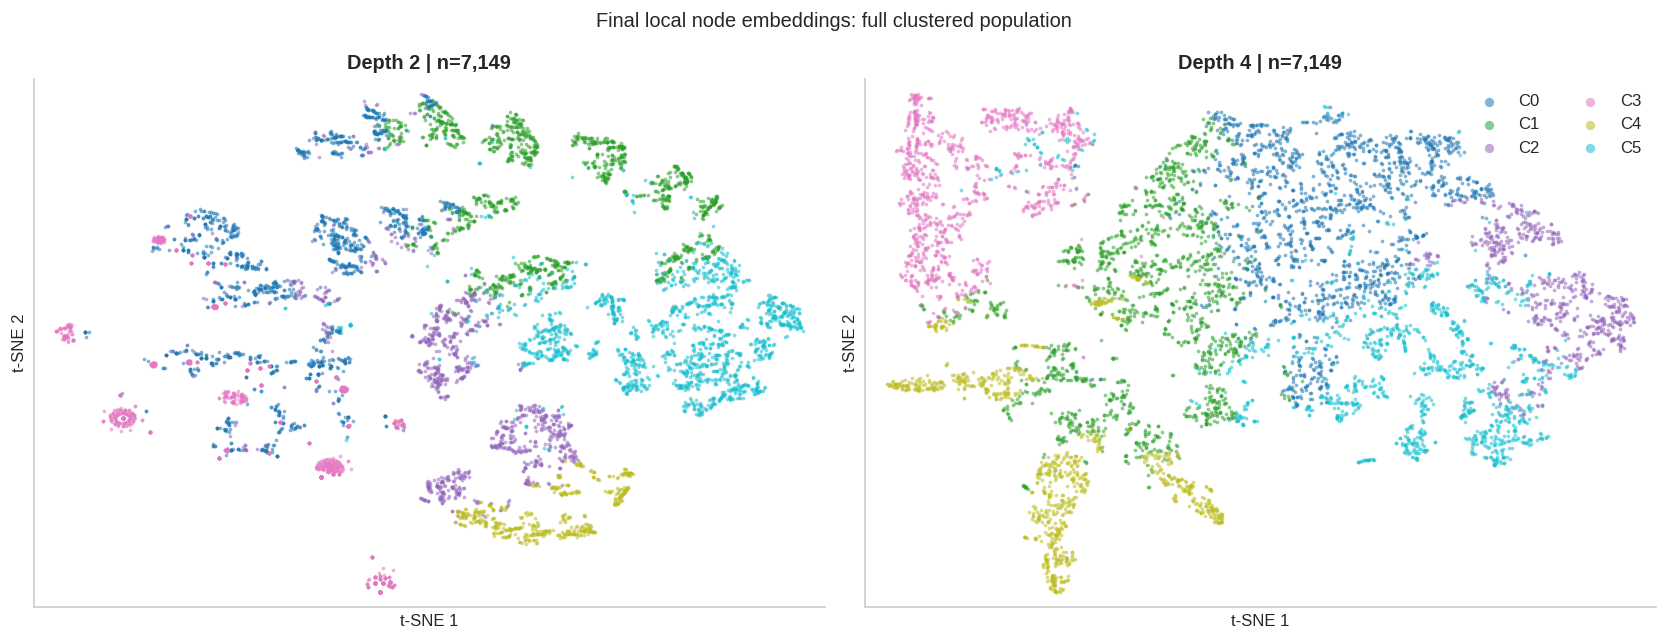

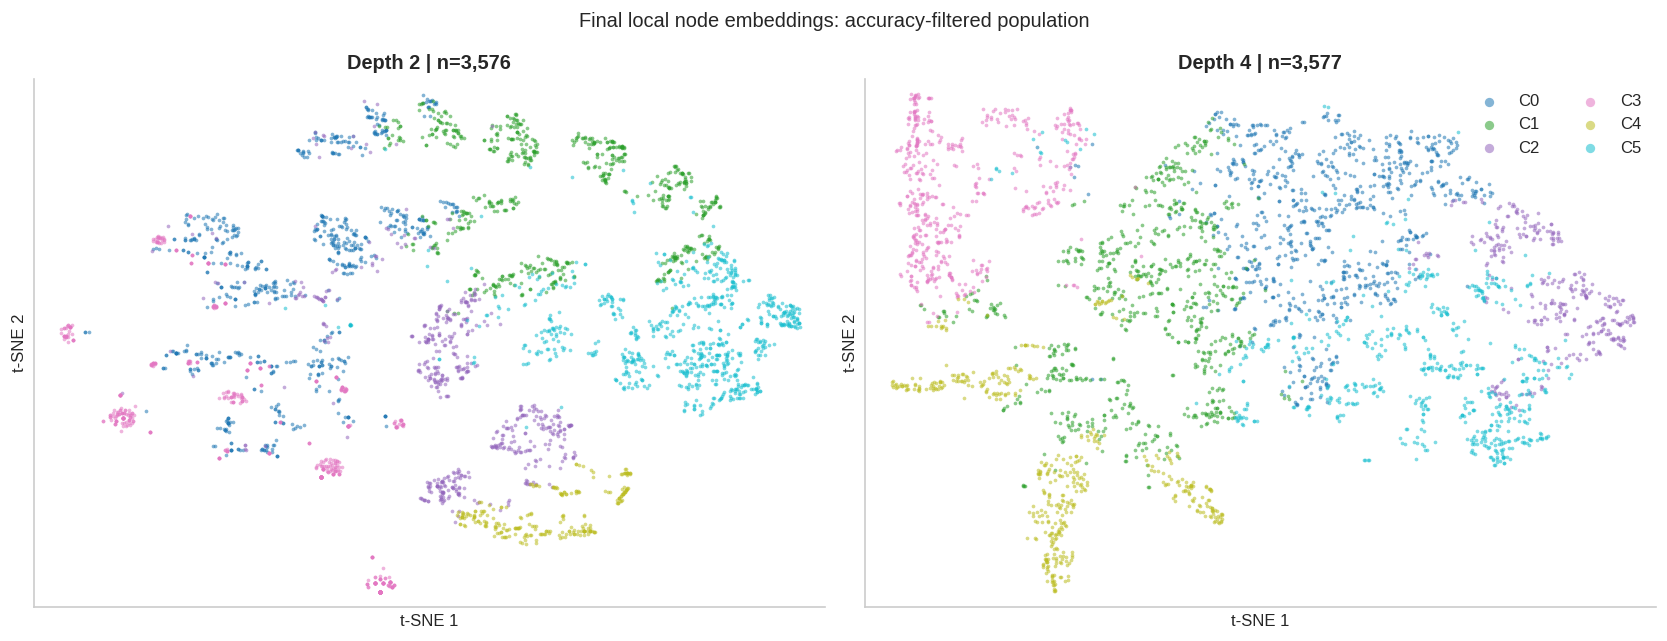

In [68]:
from sklearn.manifold import TSNE
from src.plotting.mesh_plots import cluster_color_map

cluster_colors = cluster_color_map(N_CLUSTERS, cmap_name="tab10")
tsne_tables = []
tsne_results_by_depth = {}

for depth in MODEL_DEPTHS:
    result = cluster_results_by_depth[int(depth)]
    labels = result["labels"]
    indices = stratified_tsne_indices(
        labels, TSNE_MAX_POINTS, TSNE_SEED + int(depth)
    )
    embeddings = result["clustering_result"].embeddings_used[indices]
    perplexity = min(float(TSNE_PERPLEXITY), max(5.0, (len(indices) - 1) / 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=TSNE_LEARNING_RATE,
        max_iter=TSNE_N_ITER,
        init="pca",
        random_state=TSNE_SEED,
    )
    coordinates = tsne.fit_transform(embeddings)
    labels_sample = labels[indices]
    retained_sample = result["retained_mask"][indices]
    x_span = float(np.ptp(coordinates[:, 0]))
    y_span = float(np.ptp(coordinates[:, 1]))
    x_margin = 0.03 * x_span if x_span > 0 else 1.0
    y_margin = 0.03 * y_span if y_span > 0 else 1.0
    tsne_results_by_depth[int(depth)] = {
        "coordinates": coordinates,
        "labels": labels_sample,
        "retained_mask": retained_sample,
        "x_limits": (
            float(np.min(coordinates[:, 0]) - x_margin),
            float(np.max(coordinates[:, 0]) + x_margin),
        ),
        "y_limits": (
            float(np.min(coordinates[:, 1]) - y_margin),
            float(np.max(coordinates[:, 1]) + y_margin),
        ),
    }
    tsne_tables.append(pd.DataFrame({
        "depth": int(depth),
        "row_index": indices,
        "graph_index": result["extraction"].graph_index[indices],
        "local_node_index": result["extraction"].local_node_index[indices],
        "cluster": labels_sample,
        "retained_by_accuracy_filter": retained_sample,
        "tsne_1": coordinates[:, 0],
        "tsne_2": coordinates[:, 1],
    }))


def plot_tsne_subset(subset, title, filename):
    fig, axes = plt.subplots(
        1,
        len(MODEL_DEPTHS),
        figsize=(7.0 * len(MODEL_DEPTHS), 5.4),
        squeeze=False,
    )
    for column, depth in enumerate(MODEL_DEPTHS):
        ax = axes[0, column]
        tsne_result = tsne_results_by_depth[int(depth)]
        coordinates = tsne_result["coordinates"]
        labels_sample = tsne_result["labels"]
        subset_mask = (
            np.ones(len(labels_sample), dtype=bool)
            if subset == "full"
            else tsne_result["retained_mask"]
        )
        for cluster in range(N_CLUSTERS):
            mask = subset_mask & (labels_sample == cluster)
            ax.scatter(
                coordinates[mask, 0],
                coordinates[mask, 1],
                s=5,
                alpha=0.55,
                color=cluster_colors[cluster],
                linewidths=0,
                label=f"C{cluster}",
                rasterized=True,
            )
        ax.set_title(f"Depth {depth} | n={int(subset_mask.sum()):,}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_xlim(tsne_result["x_limits"])
        ax.set_ylim(tsne_result["y_limits"])
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0, -1].legend(markerscale=2.5, ncol=2, loc="best")
    fig.suptitle(title)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()


plot_tsne_subset(
    "full",
    "Final local node embeddings: full clustered population",
    "tsne_clusters_full_by_depth",
)
plot_tsne_subset(
    "filtered",
    "Final local node embeddings: accuracy-filtered population",
    "tsne_clusters_filtered_by_depth",
)

tsne_df = pd.concat(tsne_tables, ignore_index=True)
tsne_df.to_csv(TABLES_DIR / "tsne_coordinates.csv", index=False)

## 6. Marker Composition

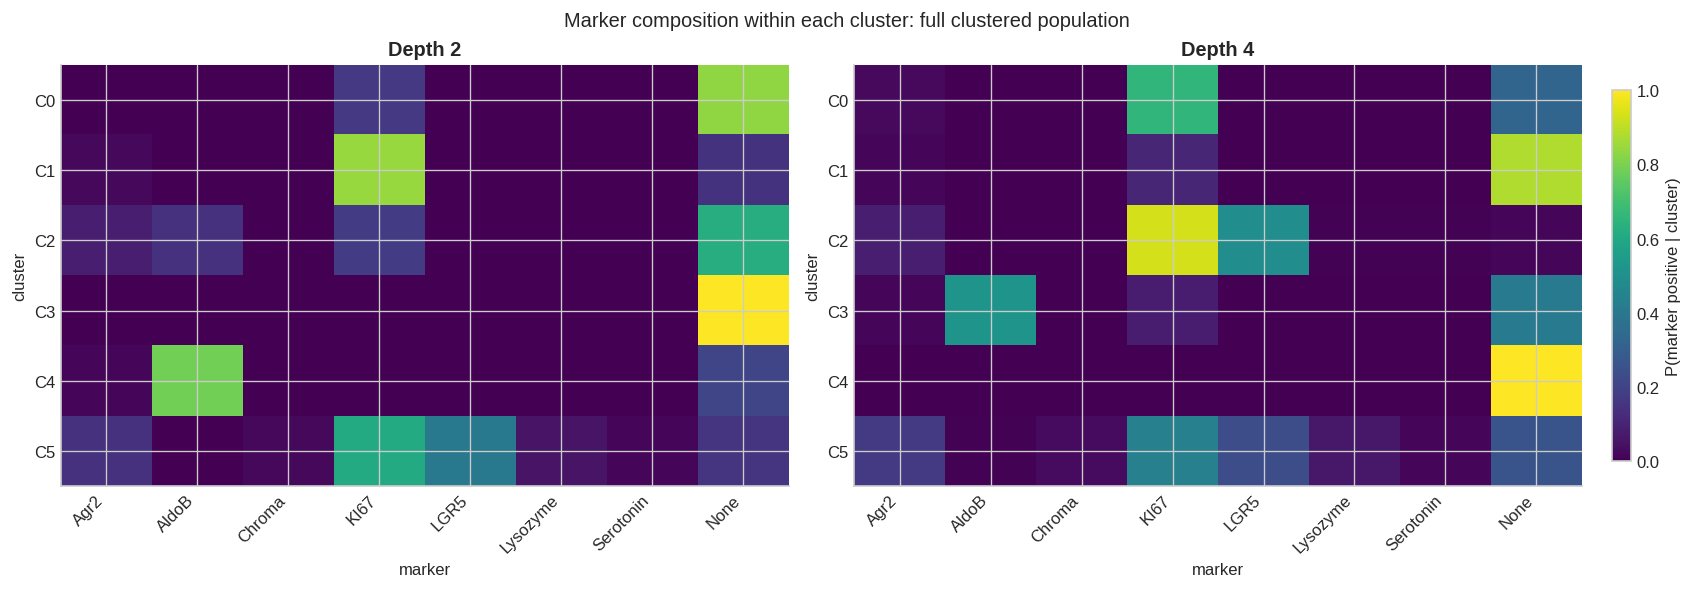

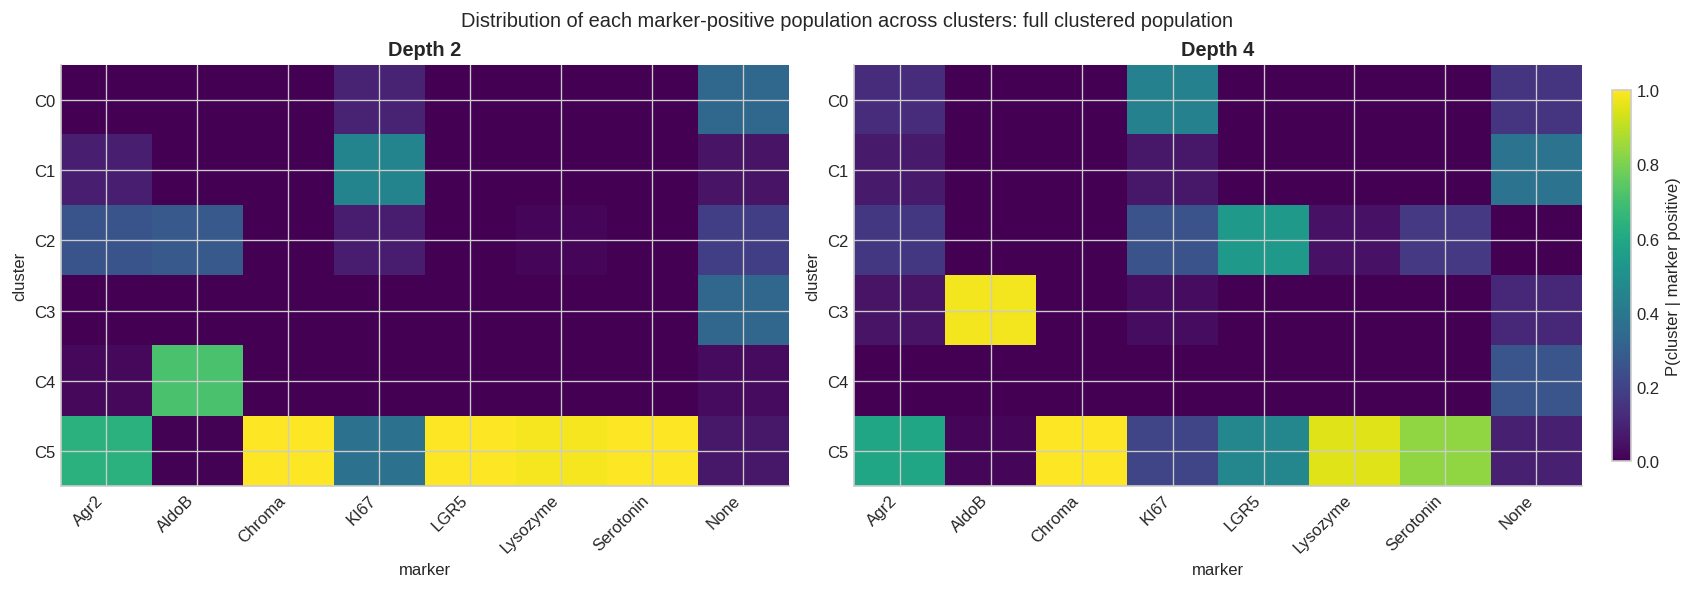

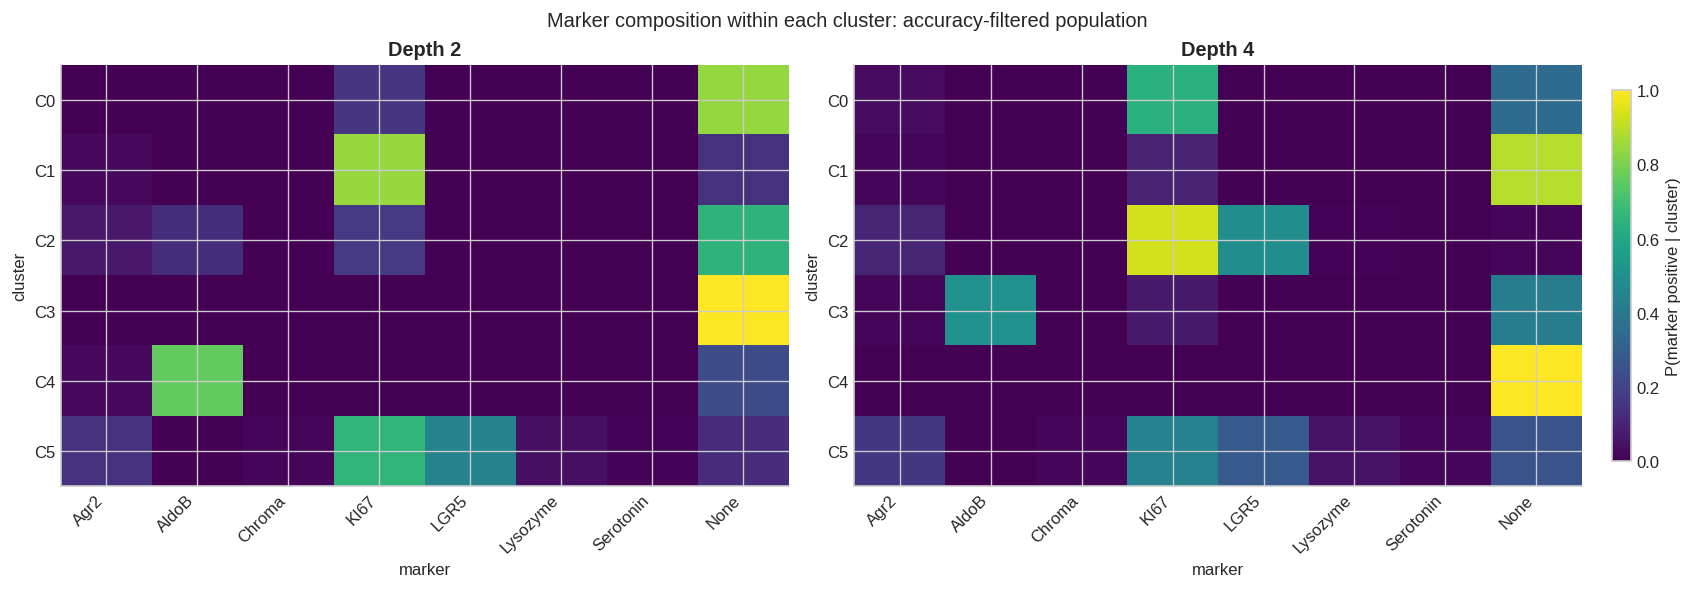

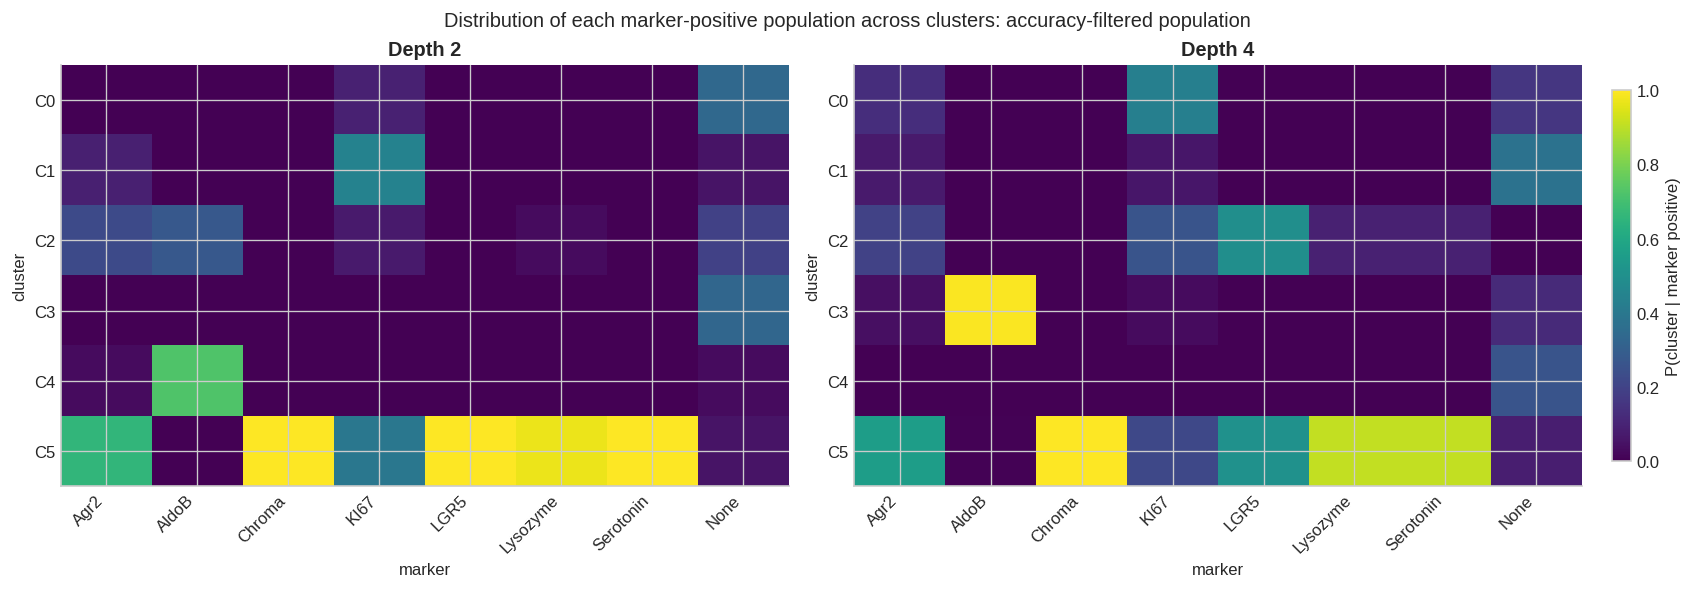

In [69]:
from src.plotting.cluster_plots import plot_cluster_marker_heatmap


def plot_marker_composition(
    value_key,
    subset_label,
    colorbar_label,
    filename,
    title,
):
    fig, axes = plt.subplots(
        1,
        len(MODEL_DEPTHS),
        figsize=(7.0 * len(MODEL_DEPTHS), 4.8),
        squeeze=False,
        constrained_layout=True,
    )
    images = []
    for column, depth in enumerate(MODEL_DEPTHS):
        ax = axes[0, column]
        result = cluster_results_by_depth[int(depth)]
        _, axis = plot_cluster_marker_heatmap(
            result[value_key],
            result["marker_names_extended"],
            title=f"Depth {depth}",
            ax=ax,
            show_colorbar=False,
            vmin=0,
            vmax=1,
            cmap="viridis",
        )
        images.append(axis.images[-1])
    colorbar = fig.colorbar(
        images[-1],
        ax=list(axes.ravel()),
        location="right",
        shrink=0.88,
        pad=0.02,
    )
    colorbar.set_label(colorbar_label)
    fig.suptitle(f"{title}: {subset_label}")
    save_mpl_figure(fig, filename)
    plt.show()


for subset_label, suffix, cluster_key, population_key in [
    (
        "full clustered population",
        "full",
        "marker_fraction_cluster",
        "marker_fraction_population",
    ),
    (
        "accuracy-filtered population",
        "filtered",
        "marker_fraction_cluster_filtered",
        "marker_fraction_population_filtered",
    ),
]:
    plot_marker_composition(
        cluster_key,
        subset_label,
        "P(marker positive | cluster)",
        f"marker_composition_fraction_of_cluster_{suffix}",
        "Marker composition within each cluster",
    )
    plot_marker_composition(
        population_key,
        subset_label,
        "P(cluster | marker positive)",
        f"marker_composition_fraction_of_population_{suffix}",
        "Distribution of each marker-positive population across clusters",
    )

## 7. Curvature By Cluster, Global Baseline Subtracted

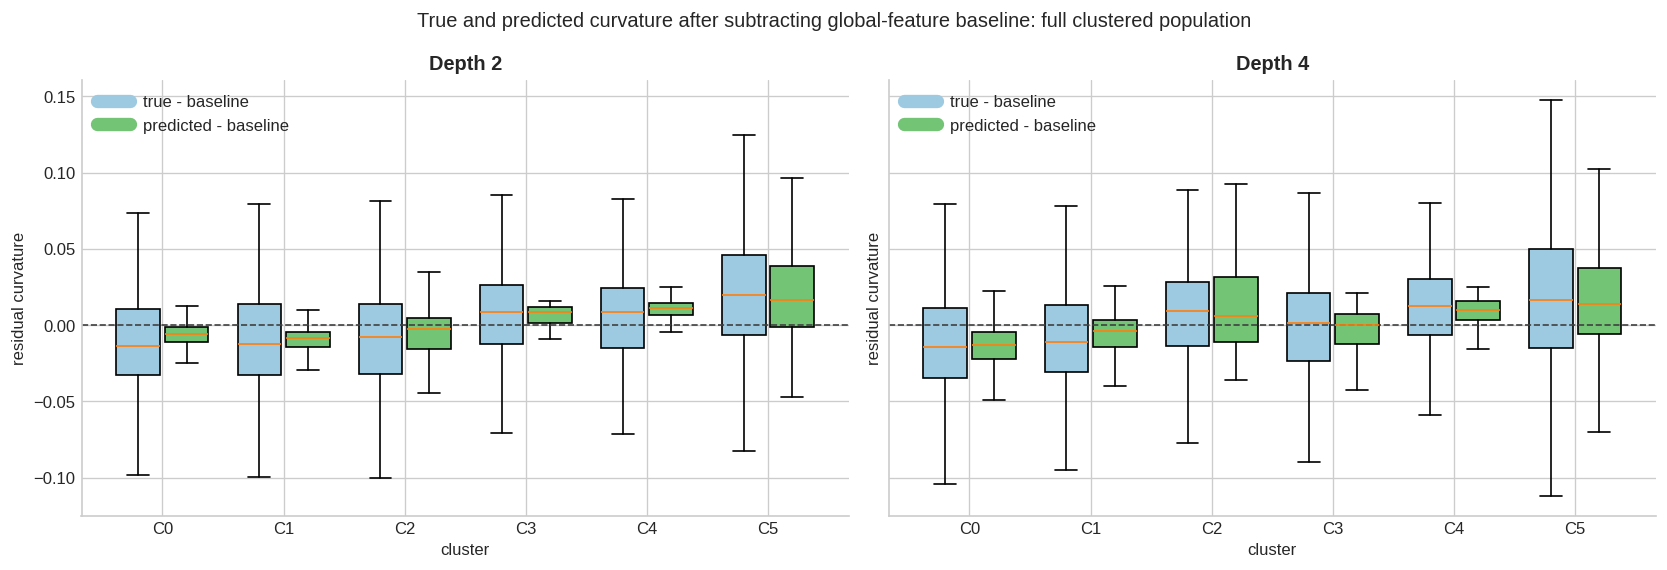

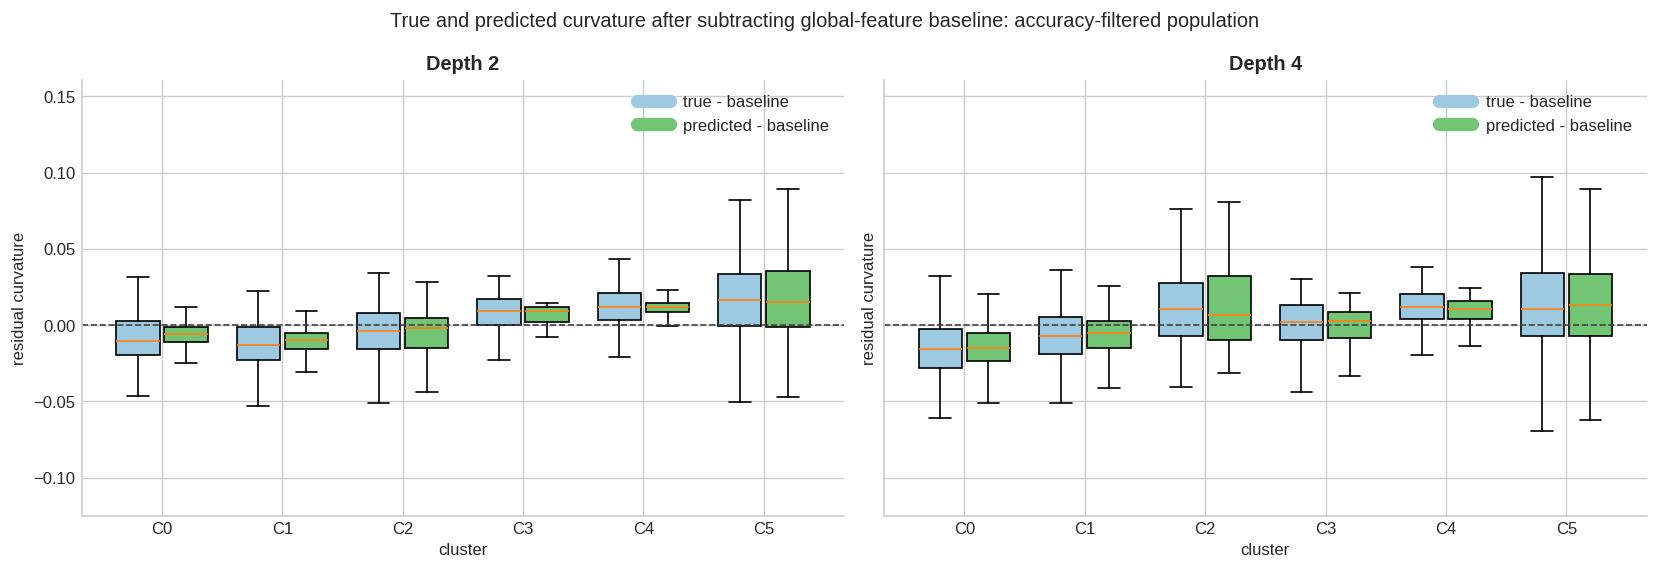

In [70]:
from src.plotting.cluster_plots import plot_cluster_boxplots


def make_curvature_boxplot_figure(subset, subset_label):
    fig, axes = plt.subplots(
        1,
        len(MODEL_DEPTHS),
        figsize=(7.0 * len(MODEL_DEPTHS), 4.8),
        squeeze=False,
        sharey=True,
    )
    for column, depth in enumerate(MODEL_DEPTHS):
        ax = axes[0, column]
        result = cluster_results_by_depth[int(depth)]
        mask = (
            np.ones(len(result["labels"]), dtype=bool)
            if subset == "full"
            else result["retained_mask"]
        )
        plot_cluster_boxplots(
            [
                (result["y_true"] - result["baseline_pred"])[mask],
                (result["y_pred"] - result["baseline_pred"])[mask],
            ],
            result["labels"][mask],
            data_labels=["true - baseline", "predicted - baseline"],
            colors=["#9ecae1", "#74c476"],
            ylabel="residual curvature",
            title=f"Depth {depth}",
            cluster_order=np.arange(N_CLUSTERS),
            show_outliers=False,
            ax=ax,
        )
        ax.axhline(0, color="0.25", linestyle="--", linewidth=1.0)
    fig.suptitle(
        "True and predicted curvature after subtracting global-feature baseline"
        f": {subset_label}"
    )
    fig.tight_layout()
    return fig, axes


curvature_figures = {}
for subset, subset_label in [
    ("full", "full clustered population"),
    ("filtered", "accuracy-filtered population"),
]:
    curvature_figures[subset] = make_curvature_boxplot_figure(
        subset, subset_label
    )

# Keep the vertical scale identical across the separately saved figures.
all_y_limits = [
    ax.get_ylim()
    for _, axes in curvature_figures.values()
    for ax in axes.ravel()
]
shared_y_limits = (
    min(limits[0] for limits in all_y_limits),
    max(limits[1] for limits in all_y_limits),
)
for subset, (fig, axes) in curvature_figures.items():
    for ax in axes.ravel():
        ax.set_ylim(shared_y_limits)
    save_mpl_figure(
        fig,
        f"cluster_curvature_boxplots_minus_global_baseline_{subset}",
    )
    display(fig)
    plt.close(fig)

## 8. Distance To Nearest Crypt Bottom

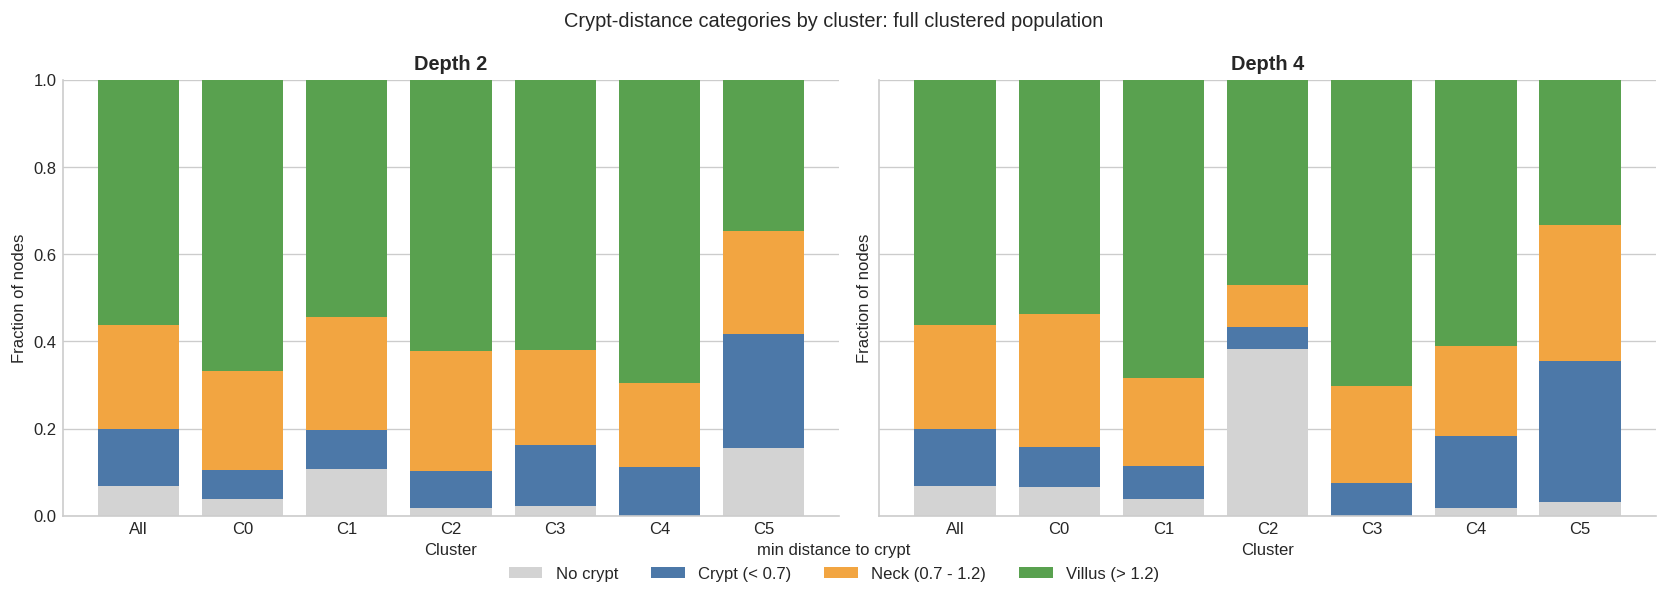

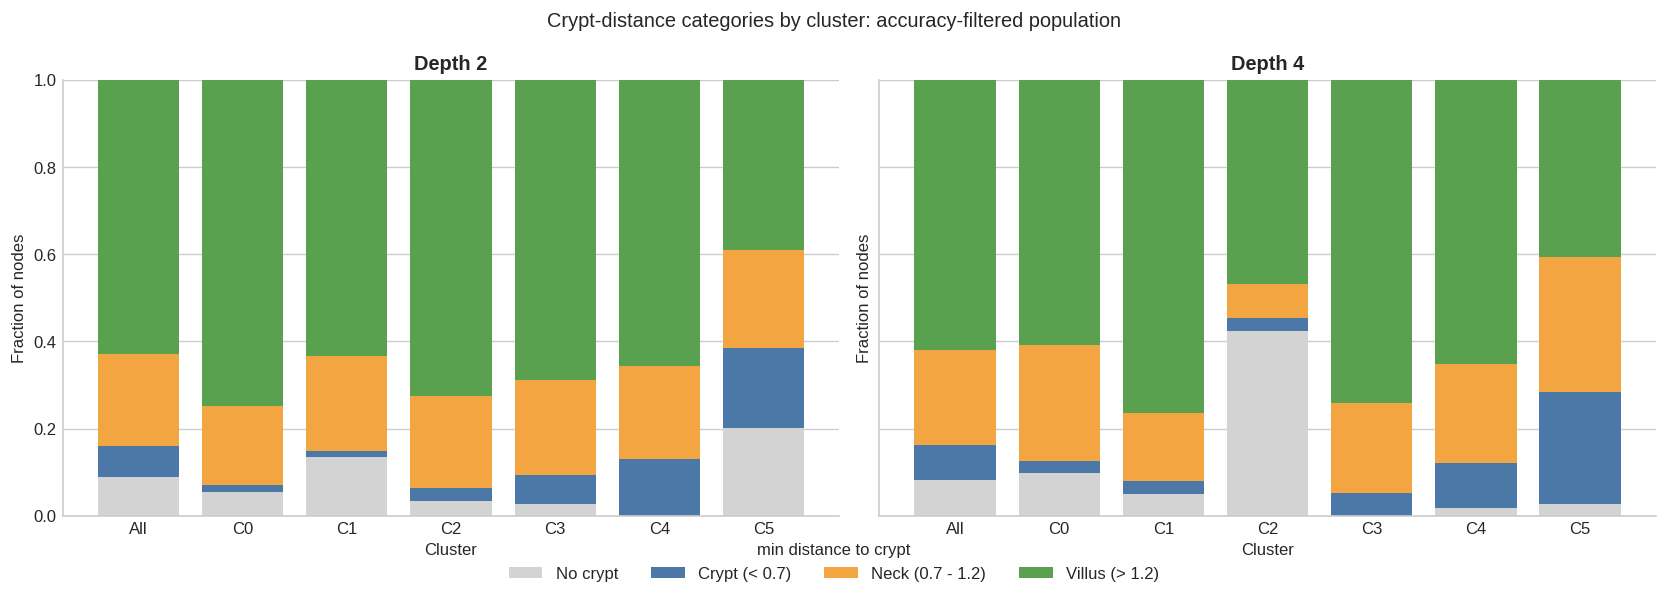

In [71]:
DCRYPT_COLORS = {
    DCRYPT_NO_CRYPT_LABEL: "lightgray",
    DCRYPT_CRYPT_LABEL: "#4C78A8",
    DCRYPT_NECK_LABEL: "#F2A541",
    DCRYPT_VILLUS_LABEL: "#59A14F",
}


def plot_dcrypt_subset(subset, subset_label, table_key, filename):
    fig, axes = plt.subplots(
        1,
        len(MODEL_DEPTHS),
        figsize=(7.0 * len(MODEL_DEPTHS), 4.8),
        squeeze=False,
        sharey=True,
    )
    for column, depth in enumerate(MODEL_DEPTHS):
        ax = axes[0, column]
        result = cluster_results_by_depth[int(depth)]
        subset_mask = (
            None if subset == "full" else result["retained_mask"]
        )
        # Recompute from raw dcrypt values so plots remain correct even when
        # thresholds are changed after the clustering cell was executed.
        table = dcrypt_fraction_table(
            result["labels"],
            result["dcrypt_values"],
            subset_mask=subset_mask,
        )
        result[table_key] = table
        bottom = np.zeros(len(table), dtype=float)
        for category in DCRYPT_BIN_ORDER:
            values = table[category].to_numpy(dtype=float)
            ax.bar(
                np.arange(len(table)),
                values,
                bottom=bottom,
                color=DCRYPT_COLORS[category],
                label=category,
                width=0.78,
            )
            bottom += np.nan_to_num(values, nan=0.0)
        tick_labels = [
            "All" if index == "All" else f"C{int(index)}"
            for index in table.index
        ]
        ax.set_xticks(np.arange(len(table)))
        ax.set_xticklabels(tick_labels)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Fraction of nodes")
        ax.set_title(f"Depth {depth}")

    handles, legend_labels = axes[0, -1].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        title="min distance to crypt",
        loc="outside lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.035),
    )
    fig.suptitle(f"Crypt-distance categories by cluster: {subset_label}")
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()


plot_dcrypt_subset(
    "full",
    "full clustered population",
    "dcrypt_plot_table",
    "dcrypt_categories_full_by_cluster",
)
plot_dcrypt_subset(
    "filtered",
    "accuracy-filtered population",
    "dcrypt_plot_table_filtered",
    "dcrypt_categories_filtered_by_cluster",
)

## 9. Cluster Exemplars

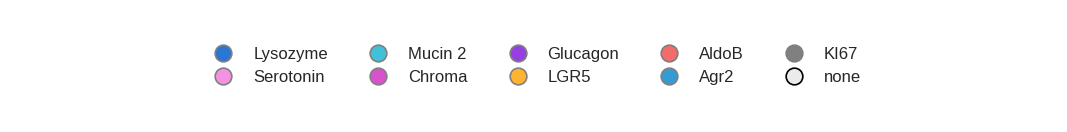

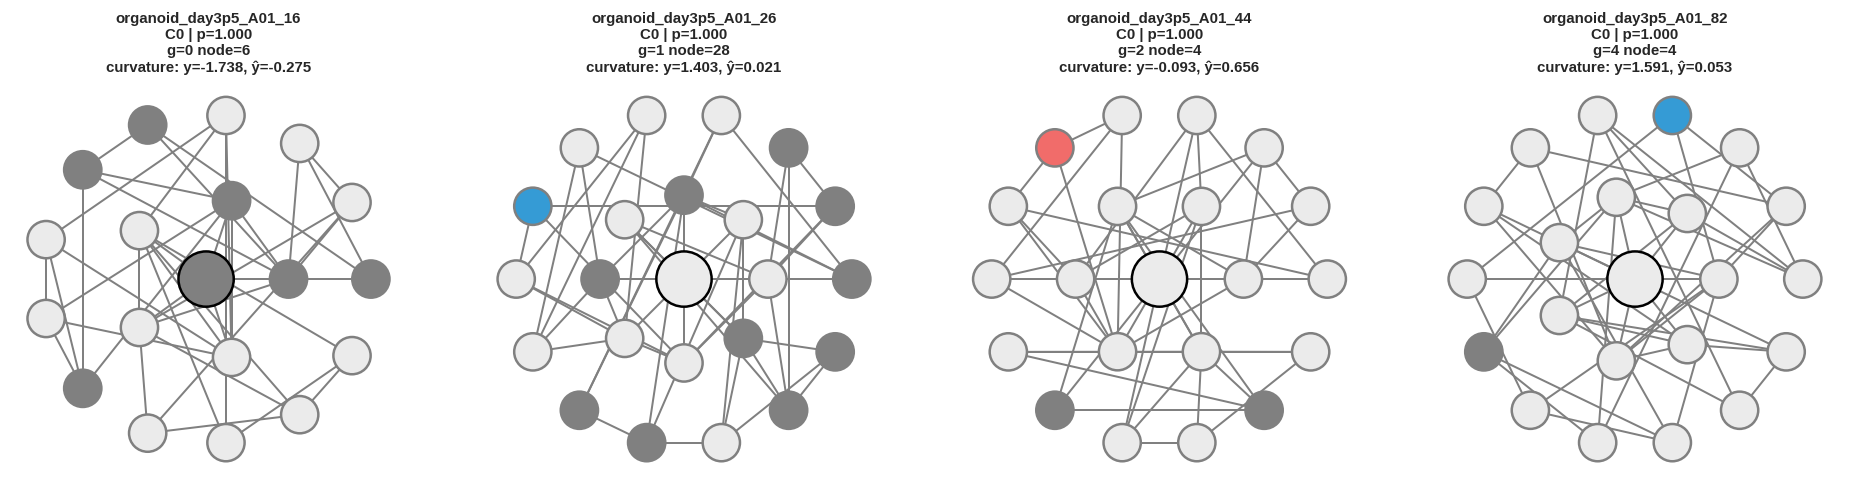

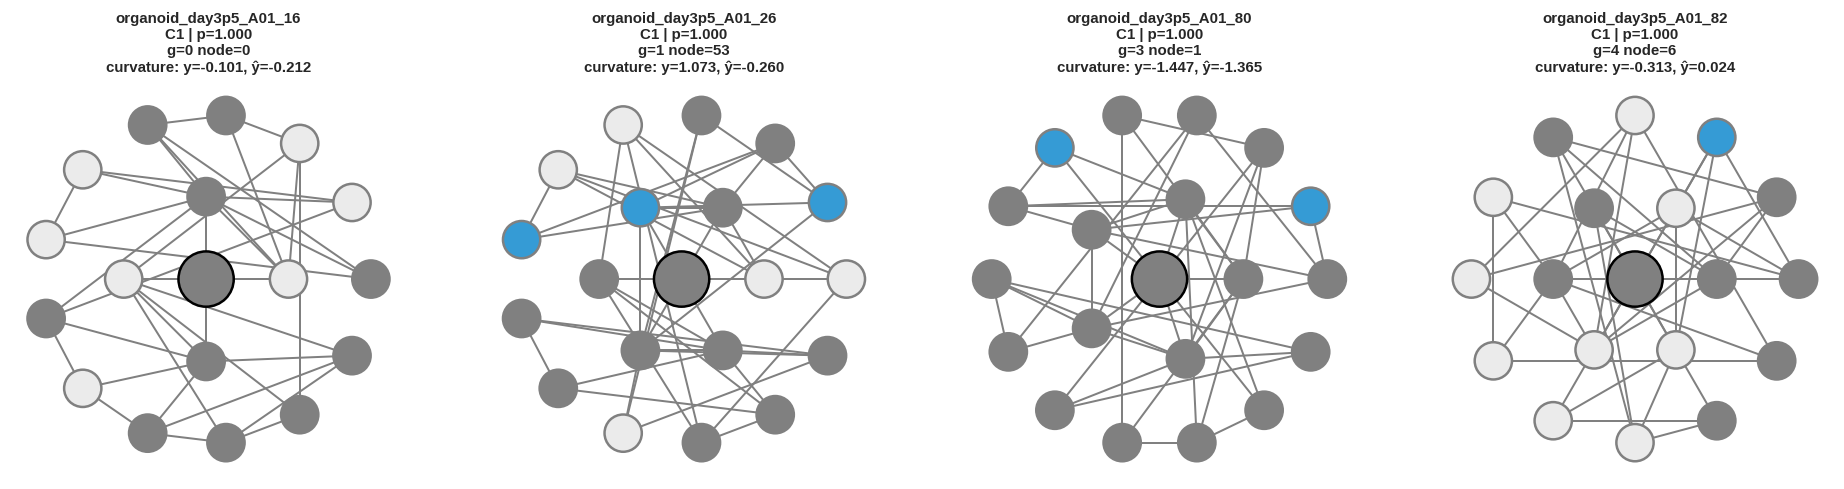

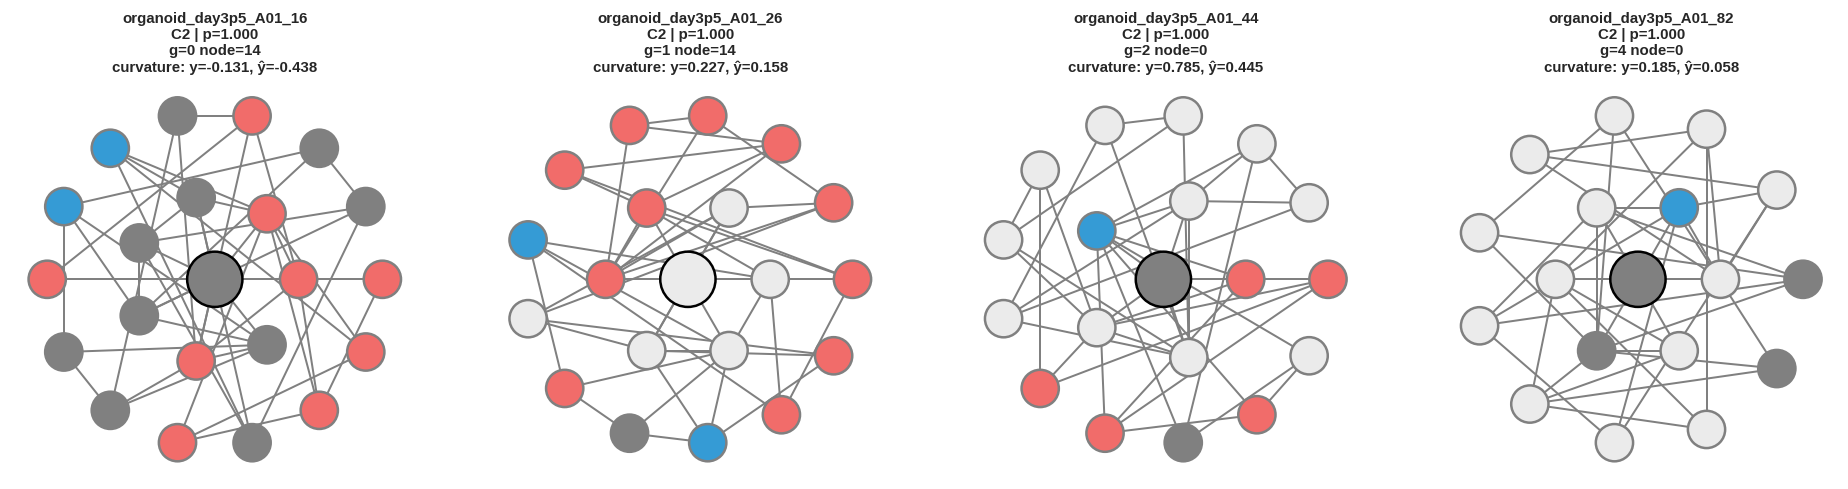

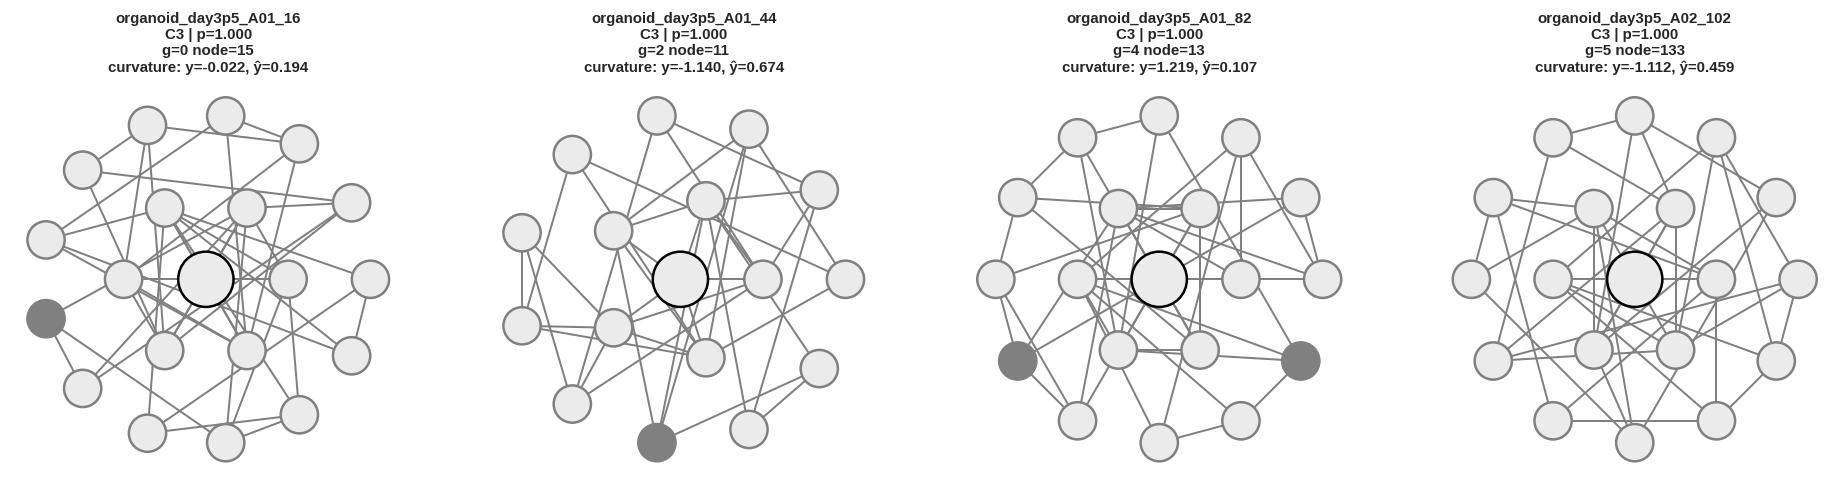

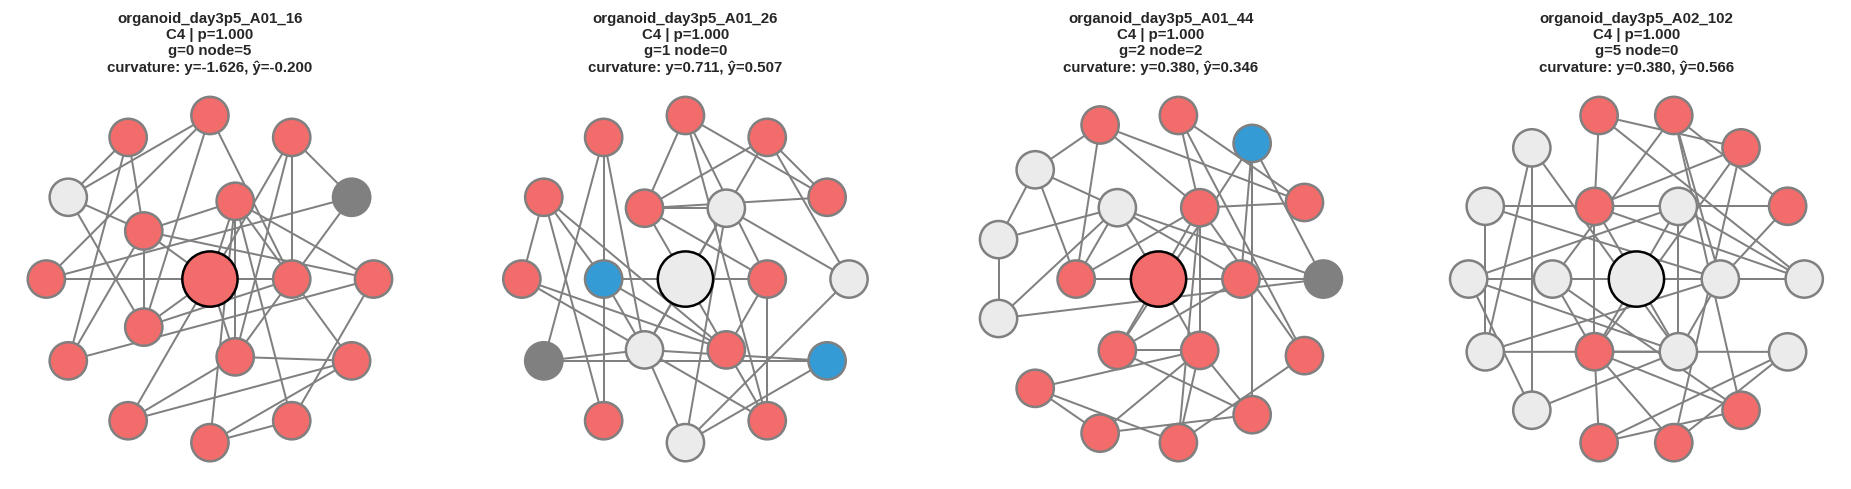

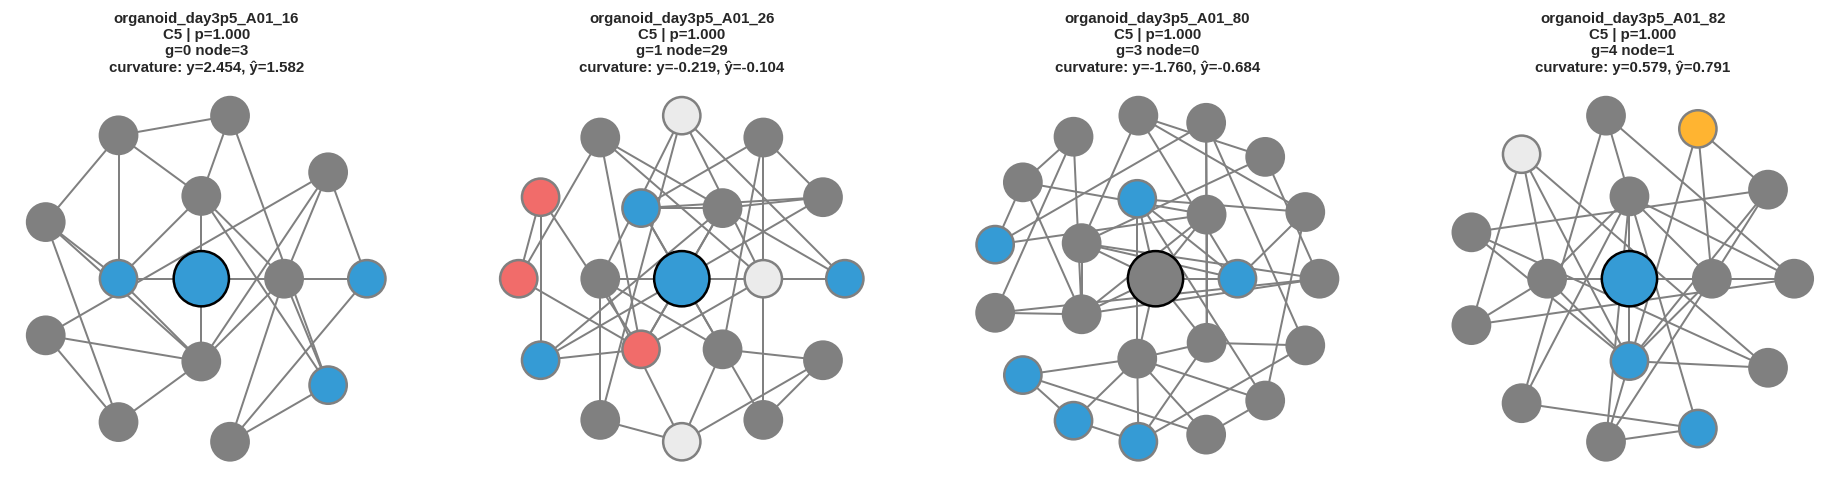

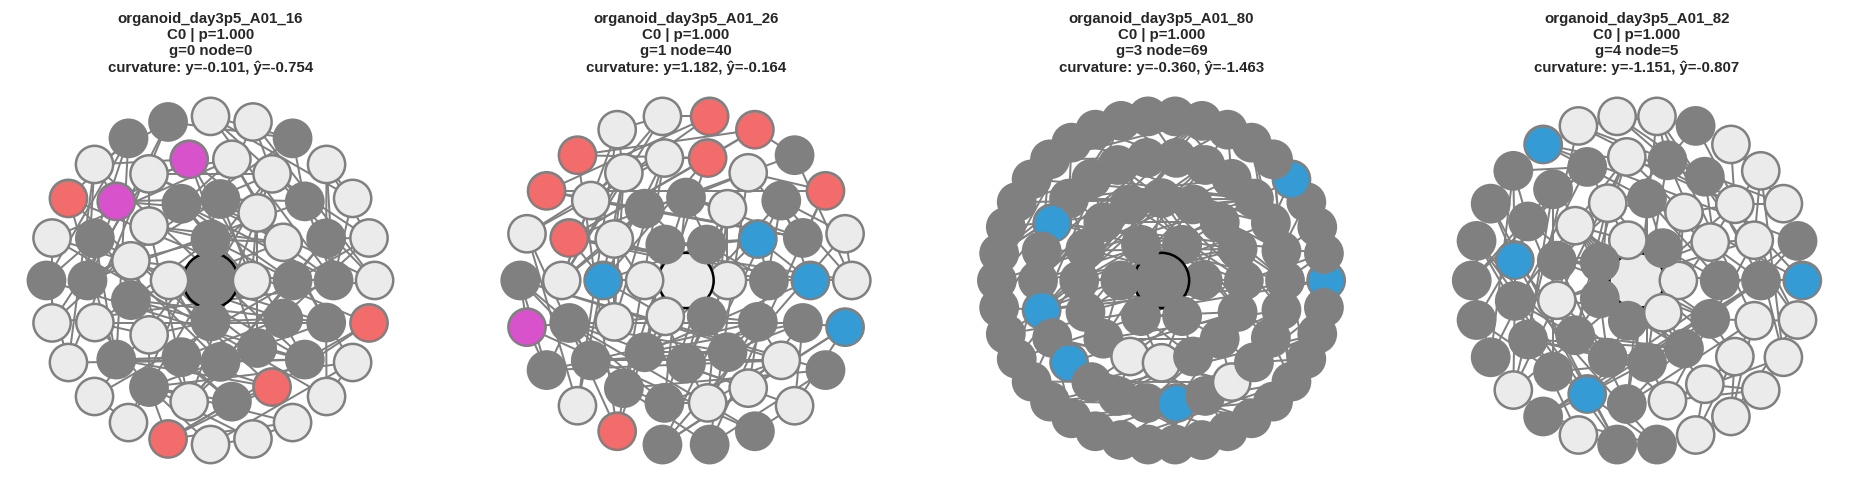

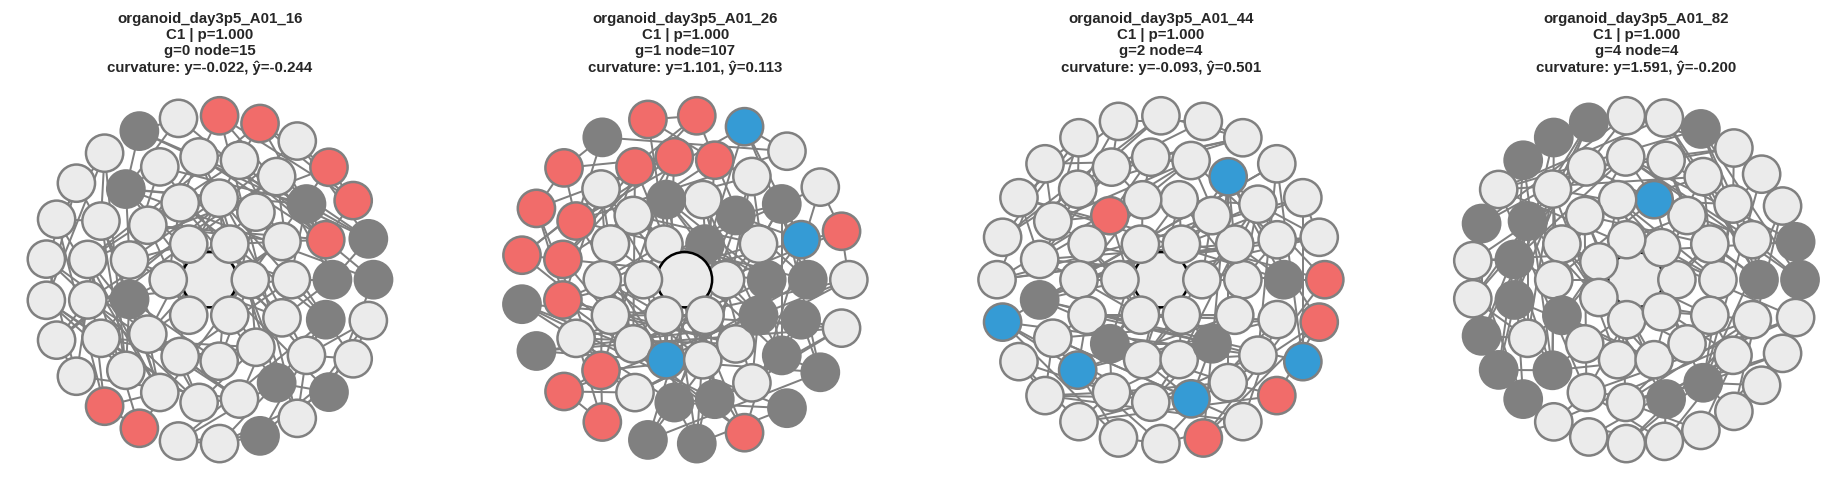

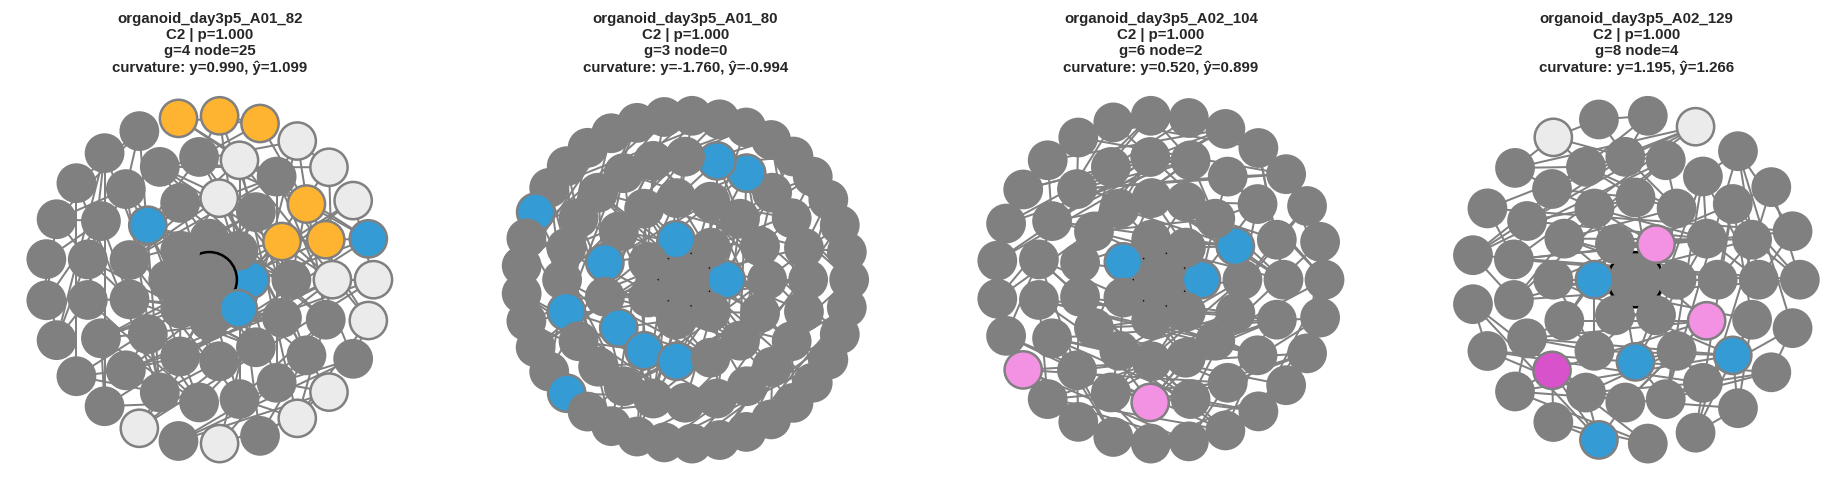

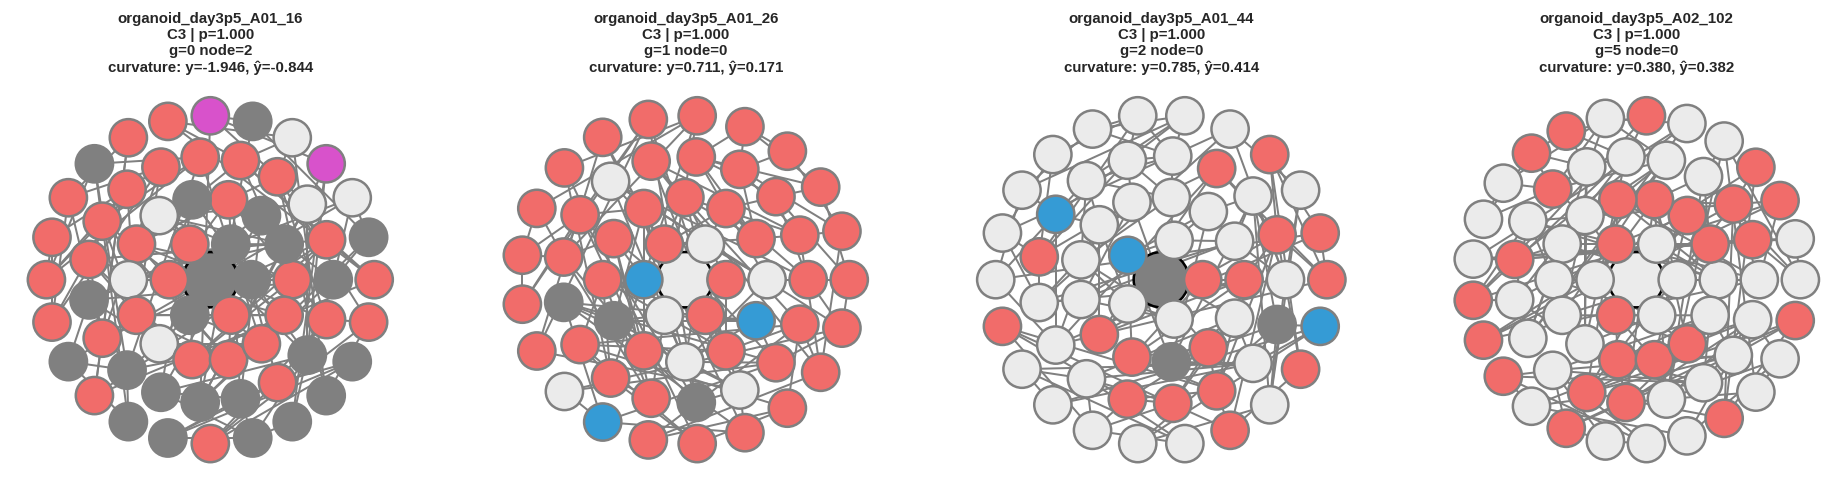

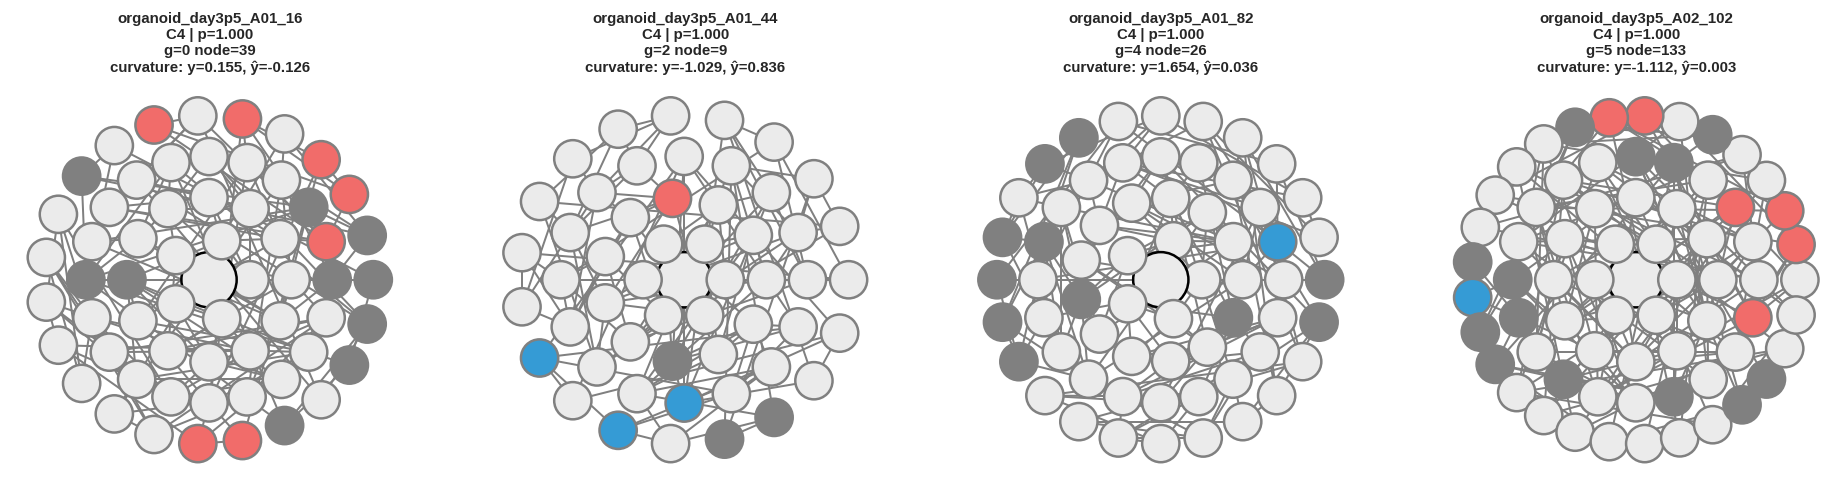

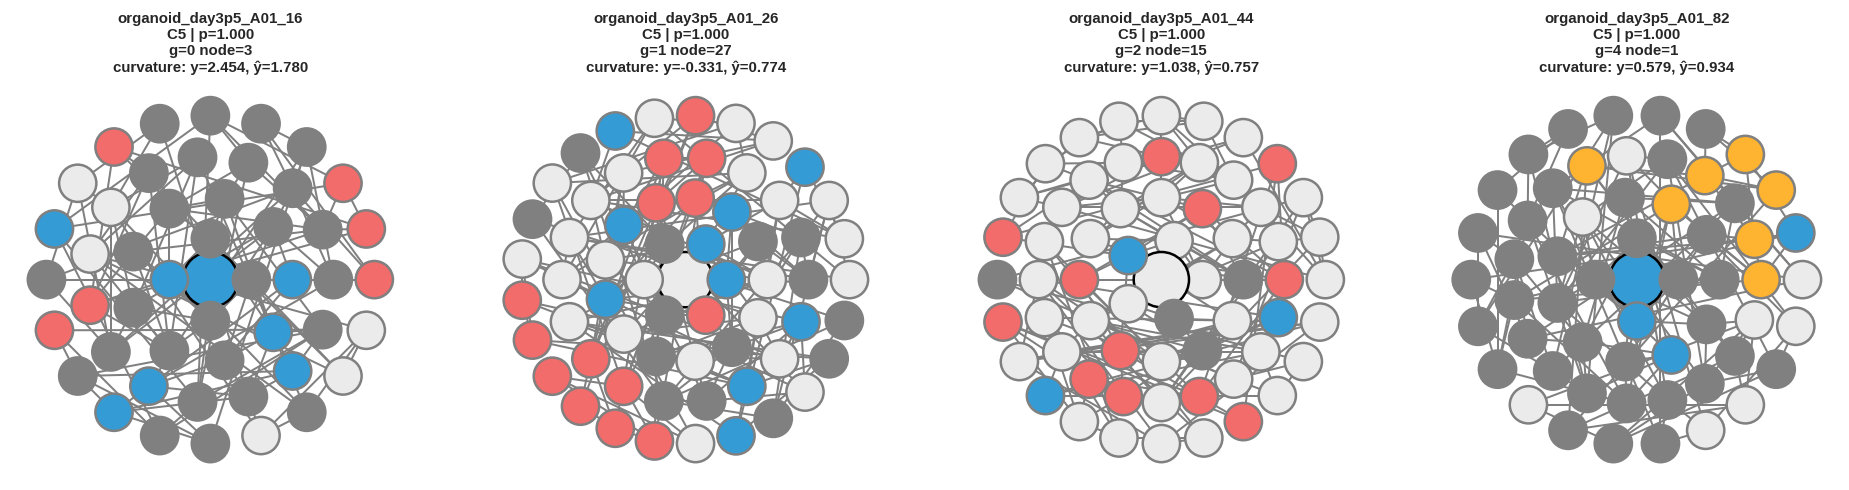

In [72]:
from src.plotting.motif_plots import (
    DEFAULT_MARKER_COLORS,
    plot_cluster_exemplar_subgraphs_radial,
    plot_marker_color_legend,
)

fig, _ = plot_marker_color_legend(marker_colors=DEFAULT_MARKER_COLORS)
save_mpl_figure(fig, "marker_color_legend")
plt.show()

for depth in MODEL_DEPTHS:
    exemplars = cluster_results_by_depth[int(depth)]["exemplars"]
    for cluster in sorted(exemplars):
        plotted = plot_cluster_exemplar_subgraphs_radial(
            exemplars,
            cluster_id=cluster,
            marker_names=marker_names,
            marker_colors=DEFAULT_MARKER_COLORS,
            target_index=TARGET_INDEX_FOR_ANALYSIS,
            target_name="curvature",
        )
        if plotted is not None:
            fig, _ = plotted
            save_mpl_figure(
                fig,
                f"radial_cluster_exemplars_depth{depth}_cluster{cluster}",
            )
        plt.show()

## 10. Forced Organoid Mesh Overview

In [73]:
from organograph.plotting.meshes import plot_organoid_mesh
from plotly.subplots import make_subplots

from src.data.splits import select_graphs_by_keys
from src.plotting.mesh_plots import (
    cluster_color_map,
    plot_categorical_mesh,
    project_cluster_categories_for_graph,
    project_marker_categories_for_graph,
    project_node_quantities_to_mesh,
)
from src.plotting.motif_plots import DEFAULT_MARKER_COLORS


def combine_three_mesh_figures(subfigures, titles, *, title, height):
    figure = make_subplots(
        rows=1,
        cols=3,
        specs=[[{"type": "scene"} for _ in range(3)]],
        subplot_titles=titles,
        horizontal_spacing=0.015,
    )
    for index, subfigure in enumerate(subfigures):
        for trace in subfigure.data:
            figure.add_trace(trace, row=1, col=index + 1)
        scene_name = "scene" if index == 0 else f"scene{index + 1}"
        if subfigure.layout.scene is not None:
            figure.layout[scene_name].update(
                subfigure.layout.scene.to_plotly_json()
            )
    figure.update_layout(
        width=1650,
        height=height,
        title=title,
        legend=dict(x=1.01, y=1.0),
    )
    return figure


selected_graphs = select_graphs_by_keys(
    g_val,
    split_info["forced_val_keys"],
    key_fn=graph_metadata_key,
    meta_lookup=val_meta_lookup,
)
if len(selected_graphs) != 1:
    raise ValueError(
        f"Expected exactly one forced validation organoid, got {len(selected_graphs)}."
    )
selected_graph = selected_graphs[0]
selected_key = graph_metadata_key(
    selected_graph, meta_lookup=val_meta_lookup
)
selected_graph_index = next(
    index
    for index, graph in enumerate(g_val)
    if graph_metadata_key(graph, meta_lookup=val_meta_lookup) == selected_key
)
start, end = graph_slice_bounds(g_val, selected_graph_index)

true_values = cluster_results_by_depth[MODEL_DEPTHS[0]]["y_true"][start:end]
prediction_values = {
    int(depth): cluster_results_by_depth[int(depth)]["y_pred"][start:end]
    for depth in MODEL_DEPTHS
}
all_numeric = np.concatenate(
    [true_values] + [prediction_values[int(depth)] for depth in MODEL_DEPTHS]
)
finite_numeric = all_numeric[np.isfinite(all_numeric)]
if CENTER_CURVATURE_AT_ZERO:
    curvature_limit = float(np.max(np.abs(finite_numeric)))
    curvature_limit = 1.0 if curvature_limit == 0 else curvature_limit
    curvature_vmin, curvature_vmax = -curvature_limit, curvature_limit
else:
    curvature_vmin = float(np.min(finite_numeric))
    curvature_vmax = float(np.max(finite_numeric))

# Curvature figure: truth plus both model depths on one shared scale.
true_projection = project_node_quantities_to_mesh(
    selected_graph,
    node_true=true_values,
    node_pred=true_values,
    meta_lookup=val_meta_lookup,
)
true_figure = plot_organoid_mesh(
    true_projection["mesh"],
    vertex_values=true_projection["mesh_true"],
    backend="plotly",
    colorscale=CURVATURE_COLORSCALE,
    center_at_zero=CENTER_CURVATURE_AT_ZERO,
    vmin=curvature_vmin,
    vmax=curvature_vmax,
    show_colorbar=True,
    view=MESH_VIEW,
    fig_size=(600, MESH_FIG_HEIGHT),
)
curvature_subfigures = [true_figure]
curvature_titles = ["True curvature"]
for depth in MODEL_DEPTHS:
    projection = project_node_quantities_to_mesh(
        selected_graph,
        node_true=true_values,
        node_pred=prediction_values[int(depth)],
        meta_lookup=val_meta_lookup,
    )
    subfigure = plot_organoid_mesh(
        projection["mesh"],
        vertex_values=projection["mesh_pred"],
        backend="plotly",
        colorscale=CURVATURE_COLORSCALE,
        center_at_zero=CENTER_CURVATURE_AT_ZERO,
        vmin=curvature_vmin,
        vmax=curvature_vmax,
        show_colorbar=False,
        view=MESH_VIEW,
        fig_size=(600, MESH_FIG_HEIGHT),
    )
    curvature_subfigures.append(subfigure)
    curvature_titles.append(f"Predicted curvature | depth {depth}")

curvature_figure = combine_three_mesh_figures(
    curvature_subfigures,
    curvature_titles,
    title=(
        f"{selected_key} | curvature"
        f"<br>shared scale [{curvature_vmin:.3g}, {curvature_vmax:.3g}]"
    ),
    height=MESH_FIG_HEIGHT,
)
save_plotly_figure(curvature_figure, "forced_organoid_curvature_meshes")
curvature_figure.show()

# Marker and cluster figure. Cluster assignments remain from the full dataset.
marker_projection = project_marker_categories_for_graph(
    selected_graph,
    marker_names=marker_names,
    marker_colors=DEFAULT_MARKER_COLORS,
    meta_lookup=val_meta_lookup,
    missing_category="none",
)
marker_figure = plot_categorical_mesh(
    marker_projection["mesh"],
    marker_projection["mesh_categories"],
    category_order=[
        marker
        for marker in DEFAULT_MARKER_COLORS
        if marker != "none" and marker in marker_names
    ],
    category_colors=DEFAULT_MARKER_COLORS,
    fig_size=(600, MESH_FIG_HEIGHT),
    view=MESH_VIEW,
    baseline_color=DEFAULT_MARKER_COLORS["none"],
    baseline_name="none",
    add_legend=True,
)
cluster_colors_raw = cluster_color_map(N_CLUSTERS, cmap_name="tab10")
cluster_colors = {
    f"C{cluster}": cluster_colors_raw[cluster]
    for cluster in range(N_CLUSTERS)
}
categorical_subfigures = [marker_figure]
categorical_titles = ["Fate markers"]
for depth in MODEL_DEPTHS:
    labels = cluster_results_by_depth[int(depth)]["labels"][start:end]
    projection = project_cluster_categories_for_graph(
        selected_graph,
        labels,
        meta_lookup=val_meta_lookup,
        missing_category=None,
    )
    subfigure = plot_categorical_mesh(
        projection["mesh"],
        projection["mesh_categories"],
        category_order=[f"C{cluster}" for cluster in range(N_CLUSTERS)],
        category_colors=cluster_colors,
        fig_size=(600, MESH_FIG_HEIGHT),
        view=MESH_VIEW,
        baseline_color="lightgray",
        baseline_name=None,
        add_legend=True,
    )
    categorical_subfigures.append(subfigure)
    categorical_titles.append(f"Clusters | depth {depth}")

categorical_figure = combine_three_mesh_figures(
    categorical_subfigures,
    categorical_titles,
    title=f"{selected_key} | fate markers and cluster assignments",
    height=MESH_FIG_HEIGHT,
)
save_plotly_figure(
    categorical_figure, "forced_organoid_marker_and_cluster_meshes"
)
categorical_figure.show()

np.savez_compressed(
    ARRAYS_DIR / "forced_organoid_node_values.npz",
    graph_index=selected_graph_index,
    true_curvature=true_values,
    predicted_depth2=prediction_values[2],
    predicted_depth4=prediction_values[4],
    clusters_depth2=cluster_results_by_depth[2]["labels"][start:end],
    clusters_depth4=cluster_results_by_depth[4]["labels"][start:end],
    marker_values=selected_graph.x.detach().cpu().numpy(),
    curvature_vmin=curvature_vmin,
    curvature_vmax=curvature_vmax,
)


ValueError: Expected exactly one forced validation organoid, got 0.

## 11. Save Settings And Compact Results

In [ ]:
settings = {
    "created_at": RUN_TIMESTAMP,
    "project_root": PROJECT_ROOT,
    "save_dir": SAVE_DIR,
    "dataset": {
        "name": DATASET_NAME,
        "target_indices": TARGET_INDICES,
        "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
        "marker_names": marker_names,
    },
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "blacklist_n_keys": len(blacklist),
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "n_graphs_after_filtering": len(graphs),
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
        "forced_val_keys": FORCED_VAL_KEYS,
        "train_keys": split_info["train_keys"],
        "val_keys": split_info["val_keys"],
    },
    "model": {
        "class": "GINCurvature",
        "depths": MODEL_DEPTHS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
        "use_global_features": USE_GLOBAL_FEATURES,
        "global_baseline_class": "GlobalFeatureMLP",
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
        "save_model_checkpoints": SAVE_MODEL_CHECKPOINTS,
    },
    "clustering": {
        "method": CLUSTERING_METHOD,
        "n_clusters": N_CLUSTERS,
        "covariance_type": CLUSTER_COVARIANCE_TYPE,
        "embedding_variant": EMBEDDING_VARIANT,
        "residualize_global_embeddings": RESIDUALIZE_GLOBAL_EMBEDDINGS,
        "standardize_embeddings": STANDARDIZE_EMBEDDINGS,
        "pca_dim": PCA_DIM,
        "seed": CLUSTER_SEED,
        "labeling": "increasing median true curvature",
    },
    "tsne": {
        "max_points": TSNE_MAX_POINTS,
        "perplexity": TSNE_PERPLEXITY,
        "learning_rate": TSNE_LEARNING_RATE,
        "n_iter": TSNE_N_ITER,
        "seed": TSNE_SEED,
        "sampling": "cluster-stratified without replacement",
    },
    "accuracy_filter": {
        "drop_fraction_within_cluster": ERROR_FILTER_DROP_FRACTION,
        "retained_fraction_within_cluster": 1.0 - ERROR_FILTER_DROP_FRACTION,
        "min_retained_per_cluster": ERROR_FILTER_MIN_RETAINED_PER_CLUSTER,
        "ranking_metric": "node-level squared prediction error",
        "cluster_assignments": "unchanged from full dataset",
    },
    "exemplars": {
        "per_cluster": EXEMPLARS_PER_CLUSTER,
        "selection_strategy": EXEMPLAR_SAMPLING_STRATEGY,
        "selection": (
            "greedy cluster-enriched marker coverage, then highest GMM "
            "membership probability; unique organoid"
            if EXEMPLAR_SAMPLING_STRATEGY == "marker_enriched"
            else "highest GMM membership probability; unique organoid"
        ),
        "radius": "equal to model depth",
        "marker_presence_scope": "anywhere in the exemplar ego-subgraph",
        "marker_threshold": EXEMPLAR_MARKER_THRESHOLD,
        "min_global_positive_nodes": EXEMPLAR_MIN_GLOBAL_POSITIVE_NODES,
        "min_cluster_positive_nodes": EXEMPLAR_MIN_CLUSTER_POSITIVE_NODES,
        "min_enrichment_ratio": EXEMPLAR_MIN_ENRICHMENT_RATIO,
        "enrichment_score": "P(marker positive | cluster) / P(marker positive)",
    },
    "dcrypt": {
        "field": DCRYPT_FIELD,
        "crypt_max": DCRYPT_CRYPT_MAX,
        "neck_max": DCRYPT_NECK_MAX,
        "bin_order": DCRYPT_BIN_ORDER,
    },
    "mesh": {
        "forced_organoid_key": selected_key,
        "view": MESH_VIEW,
        "curvature_colorscale": CURVATURE_COLORSCALE,
        "shared_curvature_vmin": curvature_vmin,
        "shared_curvature_vmax": curvature_vmax,
    },
    "results": {
        "tables_dir": TABLES_DIR,
        "arrays_dir": ARRAYS_DIR,
        "figures_dir": FIGURES_DIR,
        "node_arrays": "compressed NPZ per depth",
        "exemplar_subgraphs": "pickle per depth",
        "models_saved": SAVE_MODEL_CHECKPOINTS,
    },
}

for filename in ("settings.json", "config.json"):
    with open(SAVE_DIR / filename, "w") as handle:
        json.dump(jsonable(settings), handle, indent=2)

compact_results = {
    "cluster_summary": cluster_summary_df,
    "marker_fraction_cluster": marker_fraction_cluster_df,
    "marker_fraction_population": marker_fraction_population_df,
    "dcrypt_fraction": dcrypt_fraction_df,
    "tsne": tsne_df,
    "exemplar_metadata": exemplar_metadata_df,
    "exemplar_marker_diagnostics": exemplar_marker_diagnostics_df,
    "exemplar_selection_diagnostics": exemplar_selection_diagnostics_df,
    "accuracy_filter_summary": accuracy_filter_summary_df,
    "training_summary": training_summary_df,
}
with open(SAVE_DIR / "results.pkl", "wb") as handle:
    pickle.dump(compact_results, handle)

with open(SAVE_DIR / "meta.json", "w") as handle:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "notes": (
            "Depth-2 and depth-4 six-component embedding clustering analysis. "
            "Cluster labels are ordered by median true curvature."
        ),
    }, handle, indent=2)

print(f"Saved figures, tables, arrays, and settings to {SAVE_DIR}")

Saved figures, tables, arrays, and settings to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/clustering_analysis/depths-2-4_k6_20260611_105802
